# Assignment 3  
## CGS616: Human Centered Computing  



##  Hypothesis

Cooperation on disaster-related social media is not fixed, but emerges from repeated interactions and varies with disaster type.

- **Overall:** Cooperation declines over time as attention fades and the situation normalizes.  
- **Wildfires (slow-onset):** Cooperation starts high but gradually erodes due to prolonged exposure and fatigue; forgiving strategies (GTFT) help sustain cooperation.  
- **Earthquakes (fast-onset):** Cooperation spikes immediately (~0.80) and then declines within ~2 weeks as initial urgency fades.  
- A single bad actor (AD) cannot destabilize a TFT-based cooperative system.  
- Scale-free network structure improves resilience against isolated defectors.  
- Forgiving strategies (GTFT) are more effective than strict punishment (Grim Trigger), especially under noise and prolonged interactions.



##  Mapping to IPD

We model disaster-related social media interactions using the Iterated Prisoner’s Dilemma:

- **Cooperation (C):** Donation, support, information sharing, missing-person reporting, coordination help  
- **Defection (D):** Self-centered posts, irrelevant content, non-humanitarian or disruptive information  

This frames online disaster behavior as **strategic interaction over time**, rather than isolated actions.



##  Connection to Assignment 2

In Assignment 2, behavior was modeled as internal Markov state transitions.

Here, those same transitions are reinterpreted as outcomes of **repeated strategic interactions** in an IPD setting:
 \(P(C->C), P(C->D), P(D->C), P(D->D)\)
 are now driven by interaction dynamics between users rather than only internal stochastic changes.

This shifts the interpretation from **individual behavior modeling** to **interaction-driven emergence of cooperation**.

## Imports & Configuration

In [ ]:
# !pip install pandas numpy matplotlib networkx scipy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import rel_entr
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Label mappings
COOP_LABELS = {
    "rescue_volunteering_or_donation_effort",
    "sympathy_and_support",
    "caution_and_advice",
    "displaced_people_and_evacuations",
    "requests_or_urgent_needs",
    "missing_or_found_people",
    "injured_or_dead_people",
}
DEFECT_LABELS = {
    "not_humanitarian",
    "other_relevant_information",
    "infrastructure_and_utility_damage",
}

In [ ]:
# Disaster type mapping
DISASTER_TYPE_MAP = {
    "canada_wildfires_2016":         "wildfire",
    "kaikoura_earthquake_2016":      "earthquake",
    "puebla_mexico_earthquake_2017": "earthquake",
    "ecuador_earthquake_2016":       "earthquake",
    "italy_earthquake_aug_2016":     "earthquake",
    "hurricane_irma_2017":           "hurricane",
    "hurricane_harvey_2017":         "hurricane",
    "hurricane_maria_2017":          "hurricane",
    "hurricane_matthew_2016":        "hurricane",
    "cyclone_idai_2019":             "cyclone",
    "srilanka_floods_2017":          "flood",
}


In [ ]:
# Disaster types used in focused analysis
FOCUS_TYPES = ["wildfire", "earthquake"]
TIME_BINS   = [0, 2, 7, 14, 30, 999]
TIME_LABELS = ["Day 0-2", "Day 3-7", "Day 8-14", "Day 15-30", "Day 30+"]

In [ ]:
# IPD Payoff matrix
R, T, X, S = 3, 5, 1, 0

In [ ]:
#  Simulation hyper-parameters
N_AGENTS      = 100
N_ROUNDS      = 10
N_GENERATIONS = 50
NOISE_DEFAULT = 0.05

In [ ]:
COLORS = {
    "AC":   "#2ecc71", "AD":   "#e74c3c", "TFT":  "#3498db",
    "TF2T": "#9b59b6", "GTFT": "#f39c12", "GT":   "#1abc9c",
    "RAND": "#95a5a6", "C":    "#27ae60", "D":    "#c0392b",
}
DISASTER_COLORS = {
    "overall":    "#ffffff",
    "wildfire":   "#e74c3c",
    "earthquake": "#f39c12",
    "hurricane":  "#3498db",
    "cyclone":    "#9b59b6",
    "flood":      "#1abc9c",
}

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.facecolor":   "#0f1117",
    "axes.facecolor":     "#1a1d27",
    "axes.labelcolor":    "#e0e0e0",
    "xtick.color":        "#aaaaaa",
    "ytick.color":        "#aaaaaa",
    "text.color":         "#e0e0e0",
    "axes.titlecolor":    "#ffffff",
    "grid.color":         "#2a2d3a",
    "grid.alpha":         0.5,
})

def _ax_style(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3)



## 1. Data Loading & Processing

Each tweet is mapped to **C (Cooperation)** or **D (Defection)** and binned by days since disaster start.


In [ ]:
FILEPATH = "/content/crisisnlp_combined_dataset.csv"

df = pd.read_csv(FILEPATH)

df["tweet_time_utc"]      = pd.to_datetime(df["tweet_time_utc"],      utc=True, errors="coerce")
df["disaster_start_date"] = pd.to_datetime(df["disaster_start_date"], utc=True, errors="coerce")

df["days_since_start"] = (
    df["tweet_time_utc"] - df["disaster_start_date"]
).dt.total_seconds() / 86400

df = df[df["days_since_start"] >= 0].dropna(subset=["days_since_start", "class_label"])
df["disaster_type"] = df["disaster_name"].map(DISASTER_TYPE_MAP)
df = df.dropna(subset=["disaster_type"])

df["behavior"] = df["class_label"].apply(lambda x: "C" if x in COOP_LABELS else "D")

df["time_bin"] = pd.cut(df["days_since_start"], bins=TIME_BINS, labels=TIME_LABELS, right=True)
df = df.dropna(subset=["time_bin"])

print(f"Total tweets: {len(df):,}")
print("\nTweets per disaster type:")
print(df["disaster_type"].value_counts())
print("\nBehavior split:")
print(df["behavior"].value_counts())


Total tweets: 40,990

Tweets per disaster type:
disaster_type
hurricane     27441
earthquake     6815
cyclone        3932
wildfire       2242
flood           560
Name: count, dtype: int64

Behavior split:
behavior
C    25925
D    15065
Name: count, dtype: int64


## 2. Observed C/D Distributions & Transition Matrices

For each slice of data, we compute:
1. **C fraction per time bin** — how cooperative tweets are at each time window
2. **Transition matrix P_data** — empirical C→C, C→D, D→C, D→D probabilities


In [ ]:
def compute_observed_transitions(df_sub):
    freq_per_bin = {}
    trans_matrix = {}
    bins = list(df_sub["time_bin"].cat.categories)
    for b in bins:
        sub = df_sub[df_sub["time_bin"] == b]["behavior"]
        total = len(sub)
        if total == 0:
            continue
        c_frac = (sub == "C").sum() / total
        freq_per_bin[b] = {"C": c_frac, "D": 1 - c_frac}
        sub_full = df_sub[df_sub["time_bin"] == b].sort_values("tweet_time_utc")["behavior"].values
        counts = np.zeros((2, 2))
        idx = {"C": 0, "D": 1}
        for j in range(len(sub_full) - 1):
            counts[idx[sub_full[j]], idx[sub_full[j+1]]] += 1
        row_sums = counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        trans_matrix[b] = counts / row_sums
    return freq_per_bin, trans_matrix

# Overall (all disasters aggregated)
overall_freq, overall_trans = compute_observed_transitions(df)

# Per disaster type (wildfire & earthquake only)
disaster_freq  = {}
disaster_trans = {}
for dtype in FOCUS_TYPES:
    df_sub = df[df["disaster_type"] == dtype].copy()
    if len(df_sub) < 50:
        print(f"⚠️  Skipping {dtype} — only {len(df_sub)} tweets")
        continue
    f, t = compute_observed_transitions(df_sub)
    disaster_freq[dtype]  = f
    disaster_trans[dtype] = t
    print(f"\n{dtype.upper()} — C fractions per time bin:")
    for b, frac in f.items():
        print(f"  {b:15s}  C={frac['C']:.3f}  D={frac['D']:.3f}")

print("\nOVERALL — C fractions per time bin:")
for b, frac in overall_freq.items():
    print(f"  {b:15s}  C={frac['C']:.3f}  D={frac['D']:.3f}")



WILDFIRE — C fractions per time bin:
  Day 3-7          C=0.769  D=0.231
  Day 8-14         C=0.707  D=0.293
  Day 15-30        C=0.663  D=0.337

EARTHQUAKE — C fractions per time bin:
  Day 0-2          C=0.798  D=0.202
  Day 3-7          C=0.800  D=0.200
  Day 8-14         C=0.754  D=0.246
  Day 15-30        C=0.739  D=0.261

OVERALL — C fractions per time bin:
  Day 0-2          C=0.798  D=0.202
  Day 3-7          C=0.648  D=0.352
  Day 8-14         C=0.603  D=0.397
  Day 15-30        C=0.599  D=0.401
  Day 30+          C=0.775  D=0.225


Cooperation (C) is high immediately after disasters and then declines over time.

### Overall Disaster Cooperation Trend
Baseline: how does cooperation evolve across **all disasters** combined?


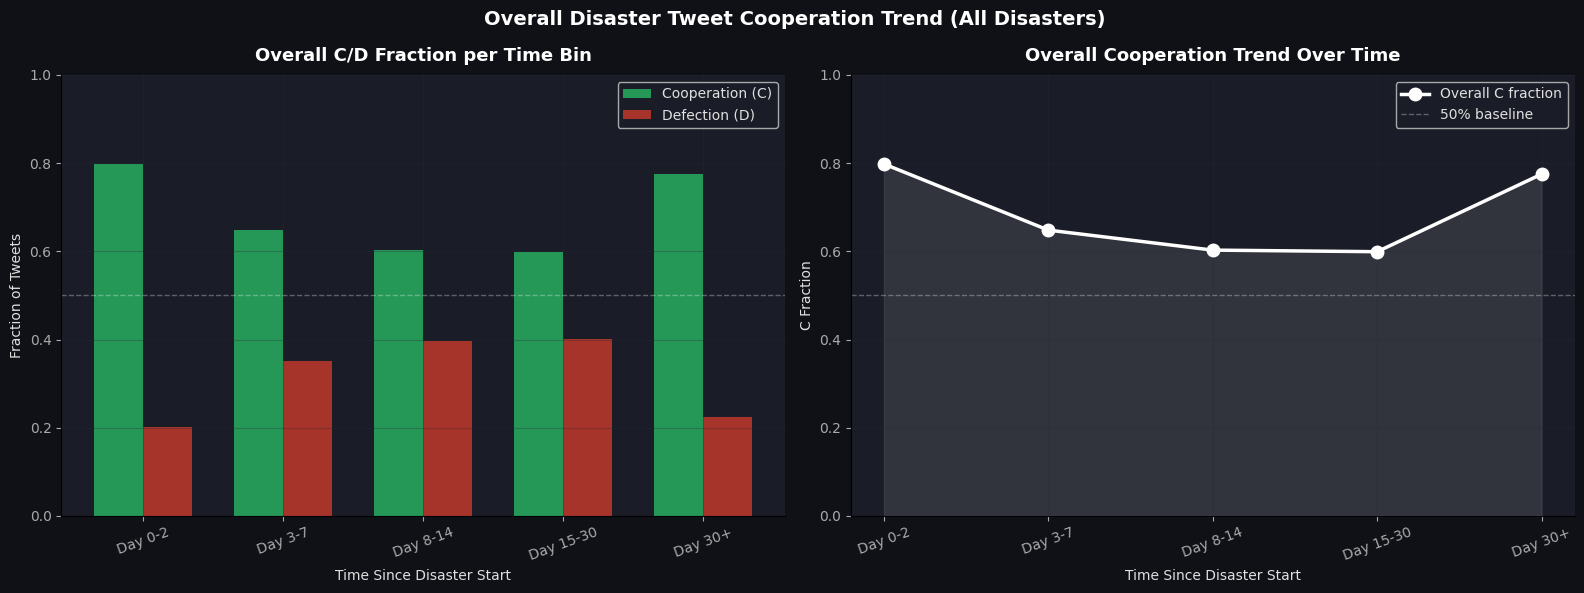

In [ ]:
overall_bins   = list(overall_freq.keys())
overall_c_vals = [overall_freq[b]["C"] for b in overall_bins]
overall_d_vals = [overall_freq[b]["D"] for b in overall_bins]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
fig.suptitle("Overall Disaster Tweet Cooperation Trend (All Disasters)",
             fontsize=14, fontweight="bold", color="white")
fig.patch.set_facecolor("#0f1117")

ax = axes[0]; ax.set_facecolor("#1a1d27")
x = np.arange(len(overall_bins)); w = 0.35
ax.bar(x - w/2, overall_c_vals, w, label="Cooperation (C)", color=COLORS["C"], alpha=0.85)
ax.bar(x + w/2, overall_d_vals, w, label="Defection (D)",   color=COLORS["D"], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(overall_bins, rotation=20)
ax.set_ylim(0, 1)
ax.axhline(0.5, ls="--", color="#ffffff", alpha=0.3, lw=1)
ax.legend(fontsize=10)
_ax_style(ax, "Overall C/D Fraction per Time Bin", "Time Since Disaster Start", "Fraction of Tweets")

# Trend line
ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
ax2.plot(overall_bins, overall_c_vals, "o-", lw=2.5, color=DISASTER_COLORS["overall"],
         markersize=9, label="Overall C fraction")
ax2.fill_between(range(len(overall_bins)), overall_c_vals, alpha=0.1, color=DISASTER_COLORS["overall"])
ax2.axhline(0.5, ls="--", color="white", alpha=0.3, lw=1, label="50% baseline")
ax2.set_ylim(0, 1); ax2.legend(fontsize=10)
ax2.set_xticks(range(len(overall_bins))); ax2.set_xticklabels(overall_bins, rotation=20)
_ax_style(ax2, "Overall Cooperation Trend Over Time", "Time Since Disaster Start", "C Fraction")

plt.tight_layout()
plt.savefig("fig0a_overall_trend.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


Across all disasters, cooperation follows a three-phase temporal pattern: an initial peak, a mid-term decline, and a later recovery. Overall cooperation starts high (0.75–0.80) and declines over time, indicating a general time-dependent decay in prosocial behavior after crises, followed by partial stabilization or recovery after Day 30.

This suggests that cooperation is not static, but dynamically shaped by how long the system remains under stress.

###  Wildfire vs Earthquake: Cross-Disaster Comparison


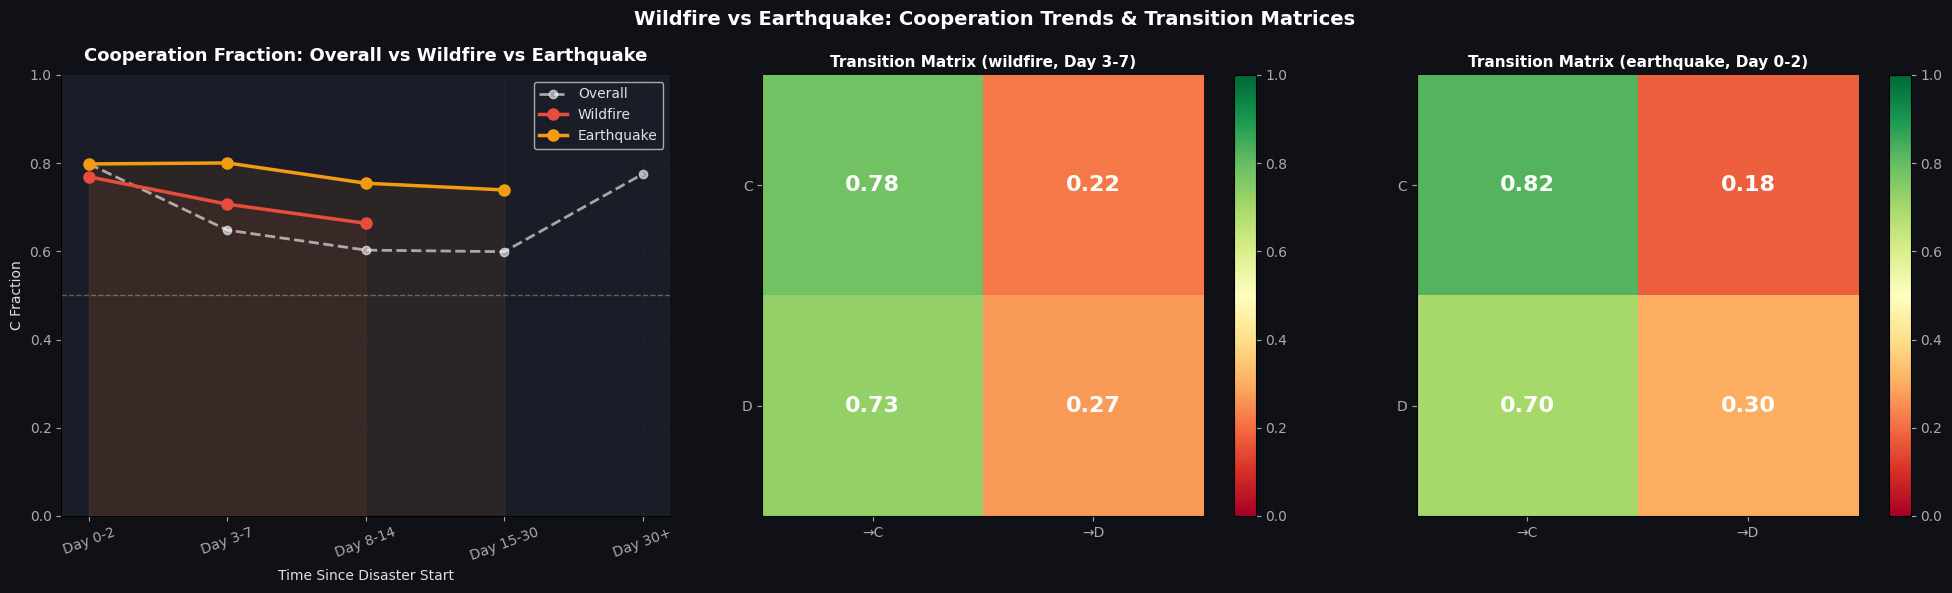

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Wildfire vs Earthquake: Cooperation Trends & Transition Matrices",
             fontsize=14, fontweight="bold", color="white")
fig.patch.set_facecolor("#0f1117")

ax = axes[0]; ax.set_facecolor("#1a1d27")
ax.plot(range(len(overall_bins)), overall_c_vals, "o--", lw=2, markersize=6,
        color=DISASTER_COLORS["overall"], label="Overall", alpha=0.6)
for dtype in list(disaster_freq.keys()):
    freq = disaster_freq[dtype]
    bins_ = list(freq.keys())
    c_vals_ = [freq[b]["C"] for b in bins_]
    ax.plot(range(len(bins_)), c_vals_, "o-", lw=2.5, markersize=8,
            color=DISASTER_COLORS[dtype], label=dtype.capitalize())
    ax.fill_between(range(len(bins_)), c_vals_, alpha=0.08, color=DISASTER_COLORS[dtype])
ax.axhline(0.5, ls="--", color="white", alpha=0.3, lw=1)
ax.set_ylim(0, 1); ax.legend(fontsize=10)
ax.set_xticks(range(len(overall_bins))); ax.set_xticklabels(overall_bins, rotation=20)
_ax_style(ax, "Cooperation Fraction: Overall vs Wildfire vs Earthquake",
          "Time Since Disaster Start", "C Fraction")

# Transition matrix heatmaps for first bin of each type
for plot_idx, dtype in enumerate(list(disaster_freq.keys())[:2]):
    ax_hm = axes[1 + plot_idx]; ax_hm.set_facecolor("#1a1d27")
    first_bin = list(disaster_trans[dtype].keys())[0]
    tm = disaster_trans[dtype][first_bin]
    im = ax_hm.imshow(tm, cmap="RdYlGn", vmin=0, vmax=1)
    ax_hm.set_xticks([0, 1]); ax_hm.set_yticks([0, 1])
    ax_hm.set_xticklabels(["→C", "→D"]); ax_hm.set_yticklabels(["C", "D"])
    for r in range(2):
        for c in range(2):
            ax_hm.text(c, r, f"{tm[r,c]:.2f}", ha="center", va="center",
                       color="white", fontsize=16, fontweight="bold")
    plt.colorbar(im, ax=ax_hm)
    ax_hm.set_title(f"Transition Matrix ({dtype}, {first_bin})",
                    fontsize=11, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig("fig0b_cross_disaster_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


Earthquakes represent fast-onset, high-intensity shocks. They show the highest initial cooperation (~0.80 at Day 0–2), along with a strong cooperative transition (P(D→C) ≈ 0.70). This indicates rapid behavioral synchronization immediately after a sudden shock, where even defectors are quickly absorbed into cooperative dynamics. Over time, cooperation declines, but the decrease is gradual rather than abrupt, stabilizing above ~0.73.


Wildfires represent slow-onset, prolonged stress environments. Cooperation begins high (~0.77) but shows a steady decline to ~0.66 over 15–30 days. Despite this erosion, transition dynamics remain stable (P(C→C) ≈ 0.78, P(D→C) ≈ 0.73), indicating persistent but weakening cooperative reinforcement over time.


## IPD Simulation Engine

This simulation models how different behavioral strategies compete over time using the Iterated Prisoner’s Dilemma framework.

### Payoff Matrix
The rewards are defined as:
- R = 3 → both cooperate (moderate reward)
- T = 5 → you defect while the other cooperates (highest reward)
- X = 1 → both defect (low reward)
- S = 0 → you cooperate while the other defects (worst outcome)

The condition **T > R > X > S** ensures a dilemma: defection gives short-term gain, but mutual cooperation is better long-term.



### Strategies
Each strategy represents a type of behavior:

- **AC (Always Cooperate):** always helps, regardless of opponent  
- **AD (Always Defect):** always acts selfishly  
- **TFT (Tit-for-Tat):** copies opponent’s last move (rewarding cooperation, punishing defection)  
- **TF2T:** more tolerant; only defects after repeated defection  
- **GTFT:** like TFT but occasionally forgives, allowing recovery from mistakes  
- **GT (Grim Trigger):** cooperates until betrayed once, then defects forever  

These map to real-world behaviors like altruism, trolling, reciprocity, tolerance, forgiveness, and strict enforcement.

### Evolution Rule
After multiple interactions:
- Each strategy accumulates a total payoff  
- Strategies that earn more payoff **increase in population**  
- Poor-performing strategies decline  

This simulates natural selection: behaviors that perform better in repeated interactions become more common over time.


In [ ]:
def play_round(s1, s2, h1, h2, noise=0.0):
    # decides what move each player makes (C or D) based on their strategy and past history
    def get_move(strategy, history):
        if strategy == "AC":
            m = "C"
        elif strategy == "AD":
            m = "D"
        elif strategy == "TFT":
            m = history[-1] if history else "C"  # copy opponent’s last move, start with C
        elif strategy == "TF2T":
            # defect only if opponent defected twice in a row
            m = "D" if (len(history) >= 2 and history[-1] == "D" and history[-2] == "D") else "C"
        elif strategy == "GTFT":
            # like TFT but sometimes forgives (randomly cooperates even after defection)
            m = ("C" if np.random.random() < 0.33 else "D") if (history and history[-1] == "D") else "C"
        elif strategy == "GT":
            m = "D" if "D" in history else "C"  # cooperate until first betrayal, then always defect
        elif strategy == "RAND":
            m = np.random.choice(["C", "D"])  # random behavior
        else:
            m = "C"  # default

        if noise > 0 and np.random.random() < noise:
            m = "D" if m == "C" else "C"

        return m

    return get_move(s1, h1), get_move(s2, h2)


def payoff(m1, m2):
    table = {
        ("C","C"):(R,R),
        ("C","D"):(S,T),
        ("D","C"):(T,S),
        ("D","D"):(X,X)
    }
    return table[(m1, m2)]


def run_ipd_simulation(strategies_init, G, n_generations=N_GENERATIONS,
                        n_rounds=N_ROUNDS, noise=0.0, track_strategies=None):

    if track_strategies is None:
        track_strategies = list(set(strategies_init))

    strategies = list(strategies_init)
    nodes      = list(G.nodes())
    history, payoff_history = [], []

    for gen in range(n_generations):
        total_payoffs = np.zeros(len(nodes))

        # each agent plays with its neighbors
        for i, u in enumerate(nodes):
            for v in list(G.neighbors(u)):
                j = nodes.index(v)

                h_u = []; h_v = []
                p_u = p_v = 0

                # repeated interaction (IPD rounds)
                for _ in range(n_rounds):
                    m_u, m_v = play_round(strategies[i], strategies[j], h_u, h_v, noise)
                    r_u, r_v = payoff(m_u, m_v)

                    p_u += r_u; p_v += r_v  # accumulate rewards
                    h_u.append(m_v); h_v.append(m_u)

                total_payoffs[i] += p_u


        freq = {s: strategies.count(s) / len(strategies) for s in track_strategies}
        history.append(freq)

        payoff_history.append(total_payoffs.mean())

        total = total_payoffs.sum()
        probs = total_payoffs / total if total > 0 else np.ones(len(nodes)) / len(nodes)

        strategies = [
            strategies[np.random.choice(len(nodes), p=probs)]
            for _ in range(len(nodes))
        ]

    return history, strategies, payoff_history


def compute_sim_transition(history):
    coop_strats = {"AC", "TFT", "TF2T", "GTFT"}

    # compute fraction of cooperation per generation
    c_fracs = [sum(v for k, v in gen.items() if k in coop_strats) for gen in history]

    counts = np.zeros((2, 2))  # transition matrix (C/D → C/D)

    for i in range(len(c_fracs) - 1):
        c1, c2 = c_fracs[i], c_fracs[i+1]

        # expected transitions based on fractions
        counts[0,0] += c1*c2
        counts[0,1] += c1*(1-c2)
        counts[1,0] += (1-c1)*c2
        counts[1,1] += (1-c1)*(1-c2)


    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1

    return counts / row_sums, c_fracs


def kl_divergence(p_data, p_sim):
    # compares simulation vs real data distributions
    p = p_data.flatten() + 1e-9
    q = p_sim.flatten() + 1e-9

    return float(np.sum(rel_entr(p, q)))  # KL divergence (lower = closer match)


def build_network(kind, n=N_AGENTS):
    # different network structures = different interaction patterns
    nets = {
        "fully_connected": lambda: nx.complete_graph(n),
        "random":          lambda: nx.erdos_renyi_graph(n, 0.1, seed=42),
        "small_world":     lambda: nx.watts_strogatz_graph(n, 6, 0.3, seed=42),
        "scale_free":      lambda: nx.barabasi_albert_graph(n, 3, seed=42),
    }
    return nets[kind]()


gens = np.arange(N_GENERATIONS)

## Base Simulation — Overall + Wildfire + Earthquake

Now we run an evolutionary IPD simulation with a fixed mix of strategies on a fully connected network for overall, wildfire, and earthquake data
Mixed population: **40% TFT + 20% AC + 20% AD + 10% GTFT + 10% GT** on a fully connected network.  
We start with a mixed set of behaviors so we can see which strategies naturally survive and best match real-world patterns.


In [ ]:
np.random.seed(42)
G_fc = build_network("fully_connected")
strategies_to_plot = ["AC", "AD", "TFT", "GTFT", "GT"]

base_results = {}

# Overall baseline first
for label, df_sub in [("overall", df)] + [(d, df[df["disaster_type"] == d]) for d in list(disaster_freq.keys())]:
    if label != "overall":
        ref_tm = list(disaster_trans[label].values())[0]
        obs_c  = [disaster_freq[label][b]["C"] for b in disaster_freq[label]]
    else:
        ref_tm = list(overall_trans.values())[0]
        obs_c  = [overall_freq[b]["C"] for b in overall_freq]

    base_strats = ["TFT"]*40 + ["AC"]*20 + ["AD"]*20 + ["GTFT"]*10 + ["GT"]*10
    np.random.shuffle(base_strats)
    init_base = list(base_strats)
    hist, final, _ = run_ipd_simulation(
        base_strats, G_fc, n_generations=N_GENERATIONS,
        track_strategies=strategies_to_plot
    )
    sim_tm, sim_c = compute_sim_transition(hist)
    kl = kl_divergence(ref_tm, sim_tm)
    base_results[label] = {
        "hist": hist, "final": final, "init": init_base,
        "kl": kl, "sim_tm": sim_tm, "sim_c": sim_c,
        "ref_tm": ref_tm, "obs_c": obs_c
    }
    print(f"{label:12s} — KL divergence (vs Day 0-2): {kl:.4f}")


overall      — KL divergence (vs Day 0-2): 0.2446
wildfire     — KL divergence (vs Day 0-2): 0.0235
earthquake   — KL divergence (vs Day 0-2): 0.3134


In [ ]:
def plot_base(label, res):
    col = DISASTER_COLORS.get(label, "#ffffff")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
    fig.suptitle(f"Base Simulation: Strategy Evolution & Leaderboard — {label.upper()}",
                 fontsize=14, fontweight="bold", color="white")

    ax = axes[0]; ax.set_facecolor("#1a1d27")
    for s in strategies_to_plot:
        vals = [h.get(s, 0) for h in res["hist"]]
        ax.plot(gens, vals, lw=2.5, label=s, color=COLORS[s])
    ax.legend(); _ax_style(ax, f"{label}", "Gen", "Frac")

    ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
    init_c  = {s: res["init"].count(s) for s in strategies_to_plot}
    final_c = {s: res["final"].count(s) for s in strategies_to_plot}
    x = np.arange(len(strategies_to_plot)); w = 0.35
    ax2.bar(x - w/2, [init_c[s] for s in strategies_to_plot], w)
    ax2.bar(x + w/2, [final_c[s] for s in strategies_to_plot], w)
    _ax_style(ax2, f"{label}", "Strategy", "Count")

    plt.show()

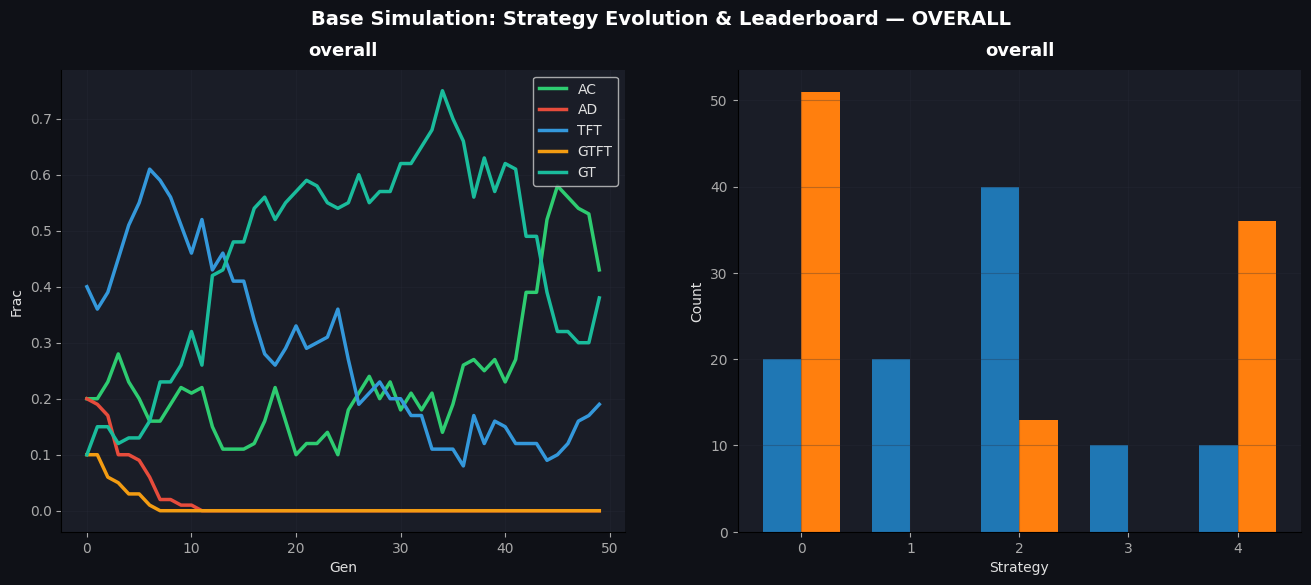

In [ ]:
plot_base("overall", base_results["overall"])

GT steadily increases and becomes dominant, while TFT declines over time. AC also gains share, while TFT weakens. This suggests that in heterogeneous environments, unconditional cooperation (AC) and strict strategies (GT) outperform purely reciprocal strategies like TFT.


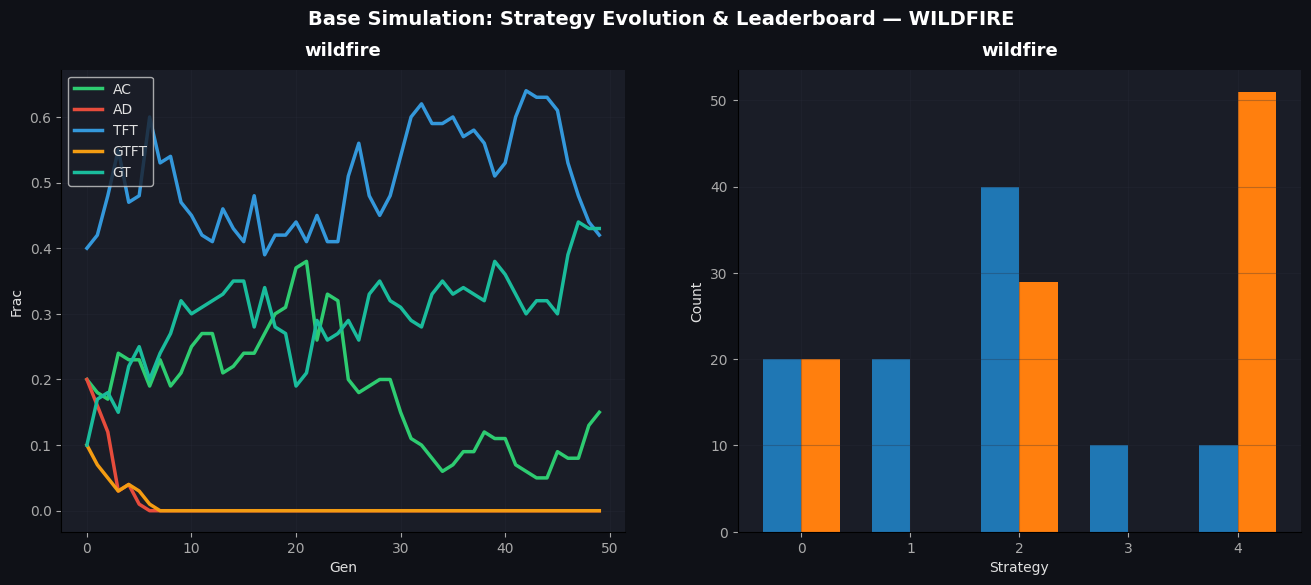

In [ ]:
plot_base("wildfire", base_results["wildfire"])

TFT remains relatively stable (≈0.5–0.6), but GT grows strongly and becomes dominant (50 agents). This indicates that in prolonged stress environments, strict enforcement strategies outperform flexible reciprocity, even though cooperation remains present throughout.


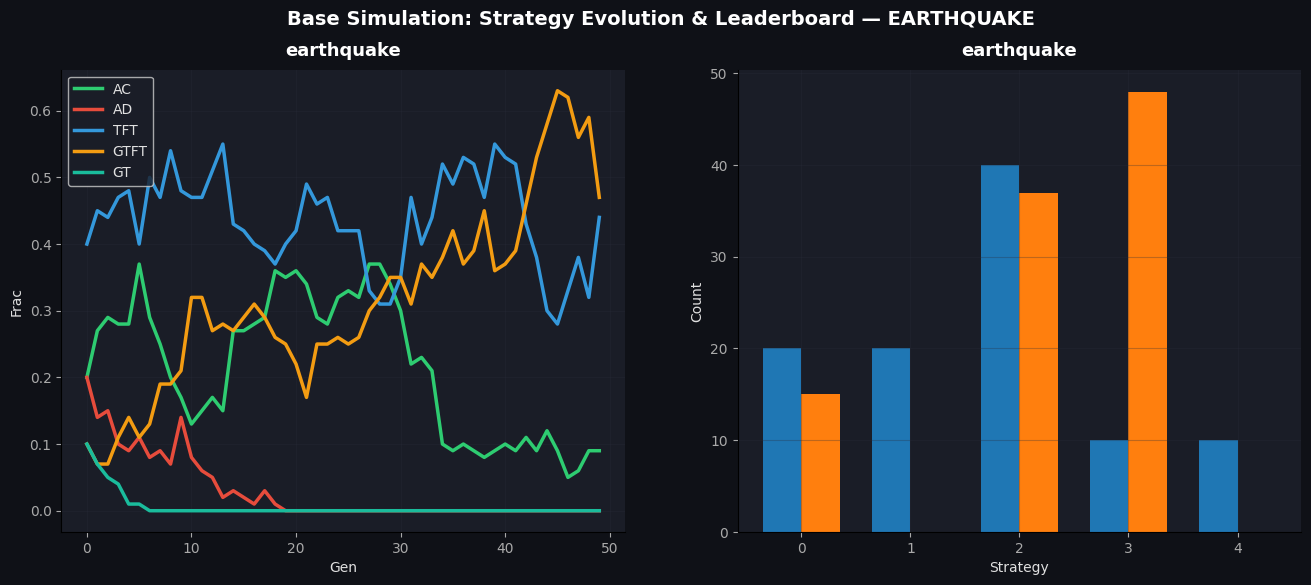

In [ ]:
plot_base("earthquake", base_results["earthquake"])

GTFT increases sharply (up to ~0.6) and becomes dominant (48 agents). This shows that in sudden shock environments, forgiving strategies that allow rapid recovery from defection are favored, because cooperation needs to re-stabilize quickly after disruption.


### Base Simulation Results

Different environments favor different strategies:  
- Mixed settings → balance of strict and cooperative strategies  
- Long-duration settings → stricter enforcement (GT) dominates  
- High-cooperation settings → forgiving strategies (GTFT) dominate


## Experiment 1 — One Bad Actor

**Question:** If a single Always Defect (AD) agent enters a TFT-dominant community, does cooperation collapse or survive?  
This models a misinformation spreader or panic account entering a cooperative disaster response community.


In [ ]:
np.random.seed(0)
bad_actor_results = {}

for label in ["overall"] + list(disaster_freq.keys()):
    strats_e1 = ["TFT"] * (N_AGENTS - 1) + ["AD"]
    np.random.shuffle(strats_e1)
    init_e1 = list(strats_e1)
    hist, final, _ = run_ipd_simulation(
        strats_e1, build_network("fully_connected"),
        n_generations=N_GENERATIONS, track_strategies=["TFT", "AD"]
    )
    _, c_fracs = compute_sim_transition(hist)
    bad_actor_results[label] = {"hist": hist, "final": final, "c_fracs": c_fracs}
    print(f"{label:12s} — Final TFT: {final.count('TFT'):3d}  AD: {final.count('AD'):3d}")


overall      — Final TFT: 100  AD:   0
wildfire     — Final TFT: 100  AD:   0
earthquake   — Final TFT: 100  AD:   0


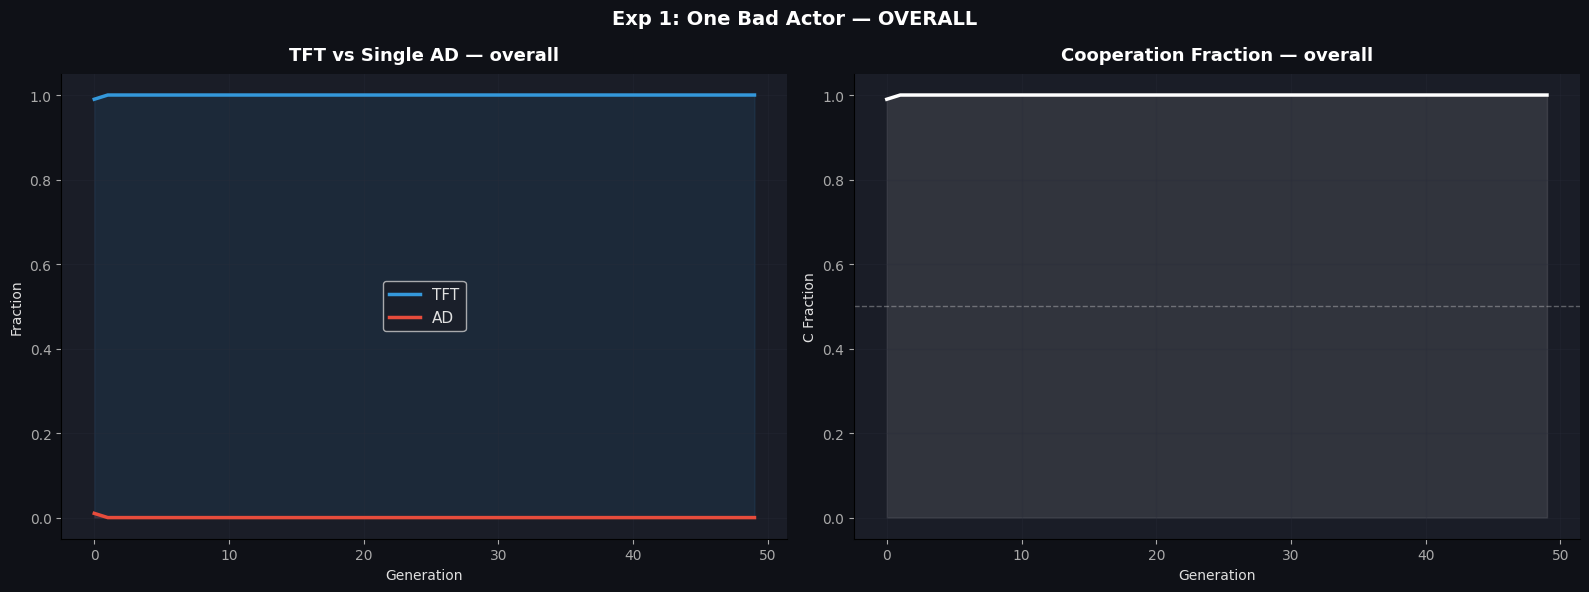

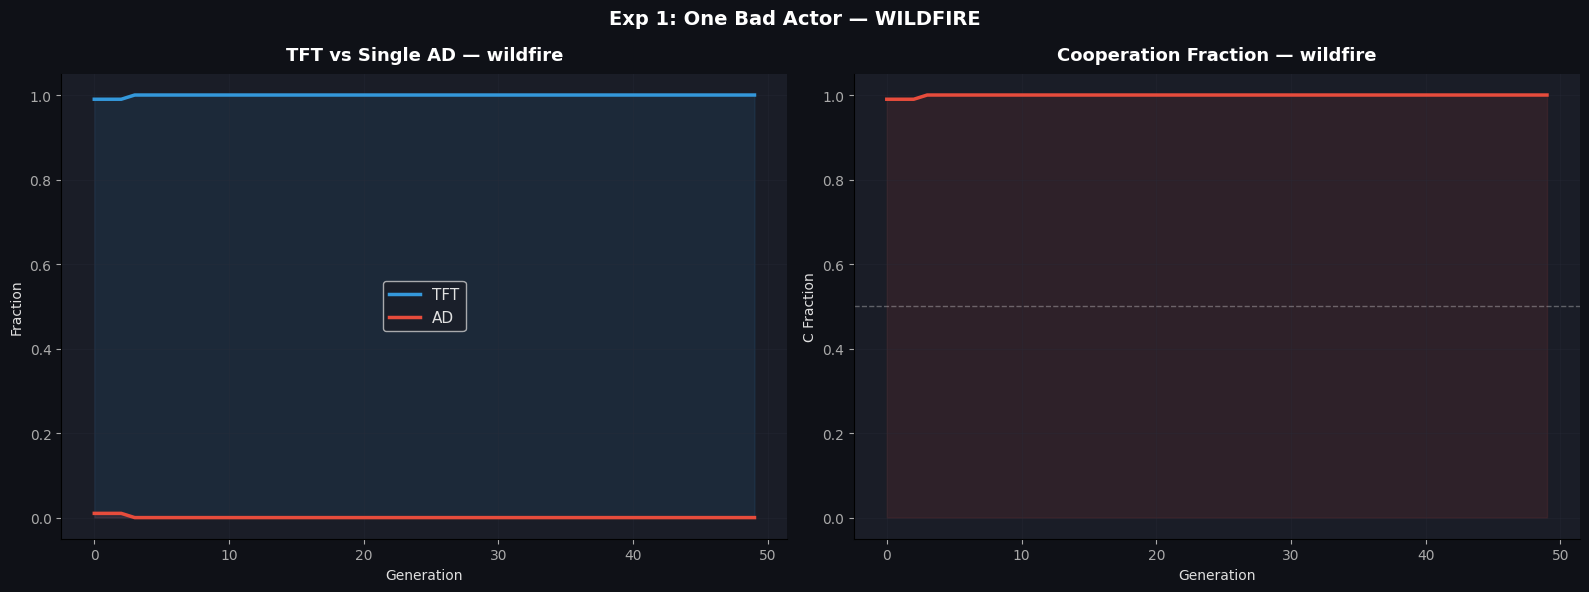

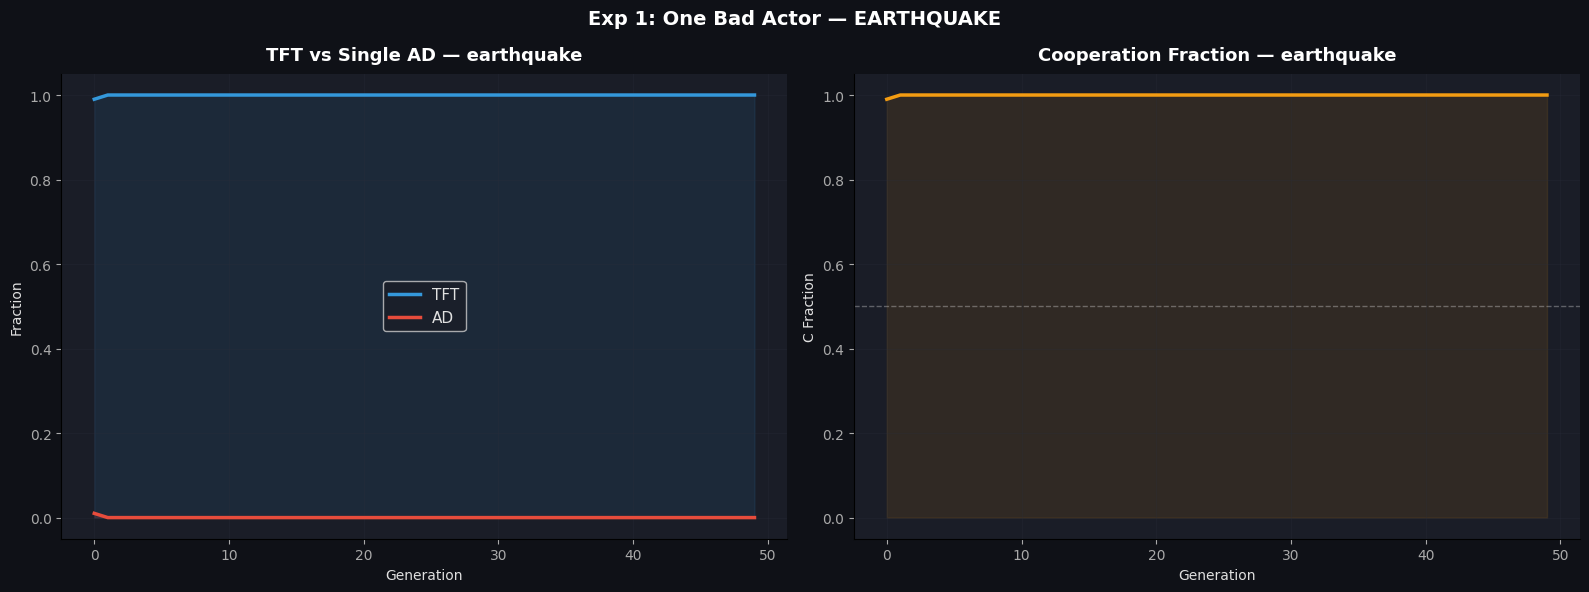

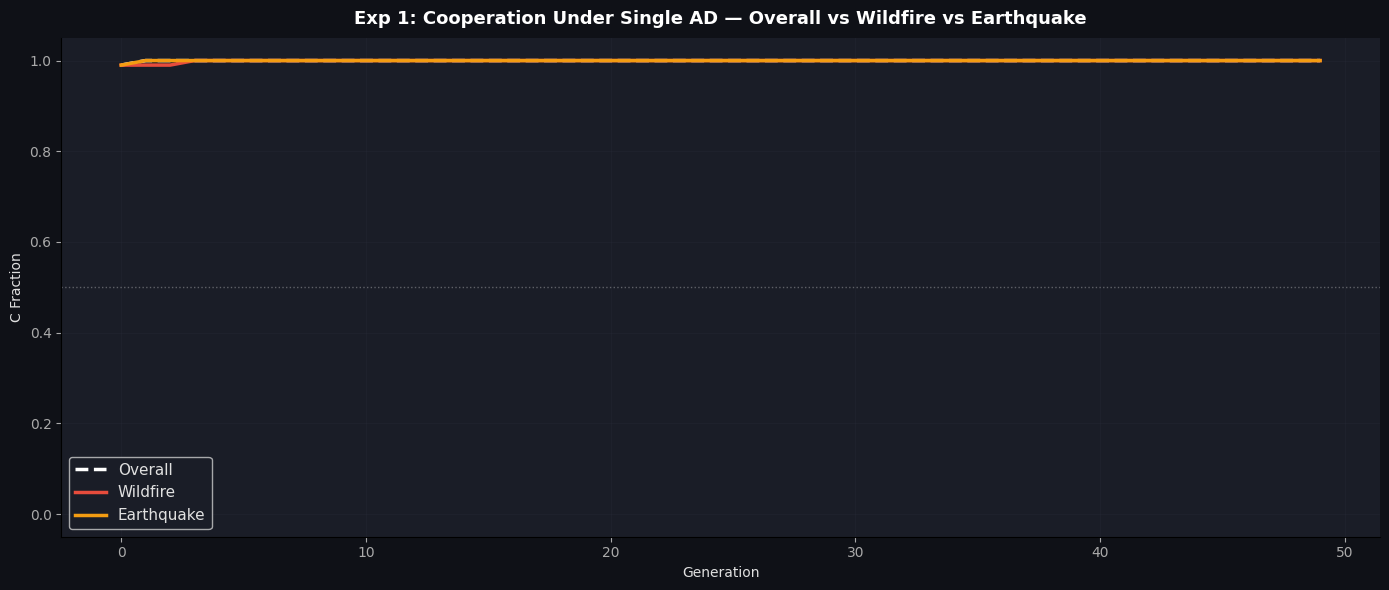

In [ ]:
for label, res in bad_actor_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
    fig.suptitle(f"Exp 1: One Bad Actor — {label.upper()}",
                 fontsize=14, fontweight="bold", color="white")
    fig.patch.set_facecolor("#0f1117")

    ax = axes[0]; ax.set_facecolor("#1a1d27")
    for s, col in [("TFT", COLORS["TFT"]), ("AD", COLORS["AD"])]:
        vals = [h.get(s, 0) for h in res["hist"]]
        ax.plot(gens, vals, lw=2.5, label=s, color=col)
        ax.fill_between(gens, vals, alpha=0.1, color=col)
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=11)
    _ax_style(ax, f"TFT vs Single AD — {label}", "Generation", "Fraction")

    ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
    ax2.plot(gens, res["c_fracs"], lw=2.5, color=DISASTER_COLORS.get(label, "#ffffff"))
    ax2.fill_between(gens, res["c_fracs"], alpha=0.1, color=DISASTER_COLORS.get(label, "#ffffff"))
    ax2.axhline(0.5, ls="--", color="white", alpha=0.3, lw=1)
    ax2.set_ylim(-0.05, 1.05)
    _ax_style(ax2, f"Cooperation Fraction — {label}", "Generation", "C Fraction")

    plt.tight_layout()
    plt.savefig(f"fig2_bad_actor_{label}.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()

# Cross-disaster comparison
fig, ax = plt.subplots(figsize=(14, 6), facecolor="#0f1117")
fig.patch.set_facecolor("#0f1117"); ax.set_facecolor("#1a1d27")
for label, res in bad_actor_results.items():
    ax.plot(gens, res["c_fracs"], lw=2.5,
            label=label.capitalize(), color=DISASTER_COLORS.get(label, "#ffffff"),
            ls="--" if label == "overall" else "-")
ax.axhline(0.5, ls=":", color="white", alpha=0.3, lw=1)
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=11)
_ax_style(ax, "Exp 1: Cooperation Under Single AD — Overall vs Wildfire vs Earthquake",
          "Generation", "C Fraction")
plt.tight_layout()
plt.savefig("fig2b_bad_actor_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


Across all environments, TFT rapidly dominates the population, while a single AD agent collapses to near zero within a few generations. Cooperation quickly rises to ~1.0 and remains stable.

In both wildfire (slow-onset) and earthquake (fast-onset) settings, AD never spreads, and TFT consistently restores full cooperation.

Insight

A single defector is insufficient to destabilize a cooperative TFT-based system, regardless of whether the environment is:

-	fast-onset (earthquake)
- slow-onset (wildfire)

Cooperation is structurally stable under isolated perturbations.

## Experiment 2 — Forgiveness Threshold Study

**Question:** Among TFT, TF2T, and GTFT — which forgiveness level best explains the real observed transitions for wildfire vs earthquake?

We pit each forgiving strategy (60 agents) against a 40% AD population and measure KL divergence against P_data. Run for overall, wildfire, and earthquake.


In [ ]:
np.random.seed(1)
forgiveness_results = {}

for label in ["overall"] + list(disaster_freq.keys()):
    if label == "overall":
        ref_tm = list(overall_trans.values())[0]
    else:
        ref_tm = list(disaster_trans[label].values())[0]

    forgiveness_results[label] = {"c_fracs": {}, "kl": {}}
    for strat_name in ["TFT", "TF2T", "GTFT"]:
        mix = [strat_name] * 60 + ["AD"] * 40
        np.random.shuffle(mix)
        h, _, _ = run_ipd_simulation(mix, build_network("fully_connected"),
                                      n_generations=N_GENERATIONS,
                                      track_strategies=[strat_name, "AD"])
        tm, cf = compute_sim_transition(h)
        forgiveness_results[label]["c_fracs"][strat_name] = cf
        forgiveness_results[label]["kl"][strat_name] = kl_divergence(ref_tm, tm)

    print(f"\n{label.upper()} — Forgiveness KL divergences:")
    for s, kl in forgiveness_results[label]["kl"].items():
        print(f"  {s:6s}: {kl:.4f}")



OVERALL — Forgiveness KL divergences:
  TFT   : 0.3682
  TF2T  : 0.2870
  GTFT  : 0.5366

WILDFIRE — Forgiveness KL divergences:
  TFT   : 0.5677
  TF2T  : 0.4789
  GTFT  : 1.5941

EARTHQUAKE — Forgiveness KL divergences:
  TFT   : 0.3899
  TF2T  : 0.3927
  GTFT  : 0.1151


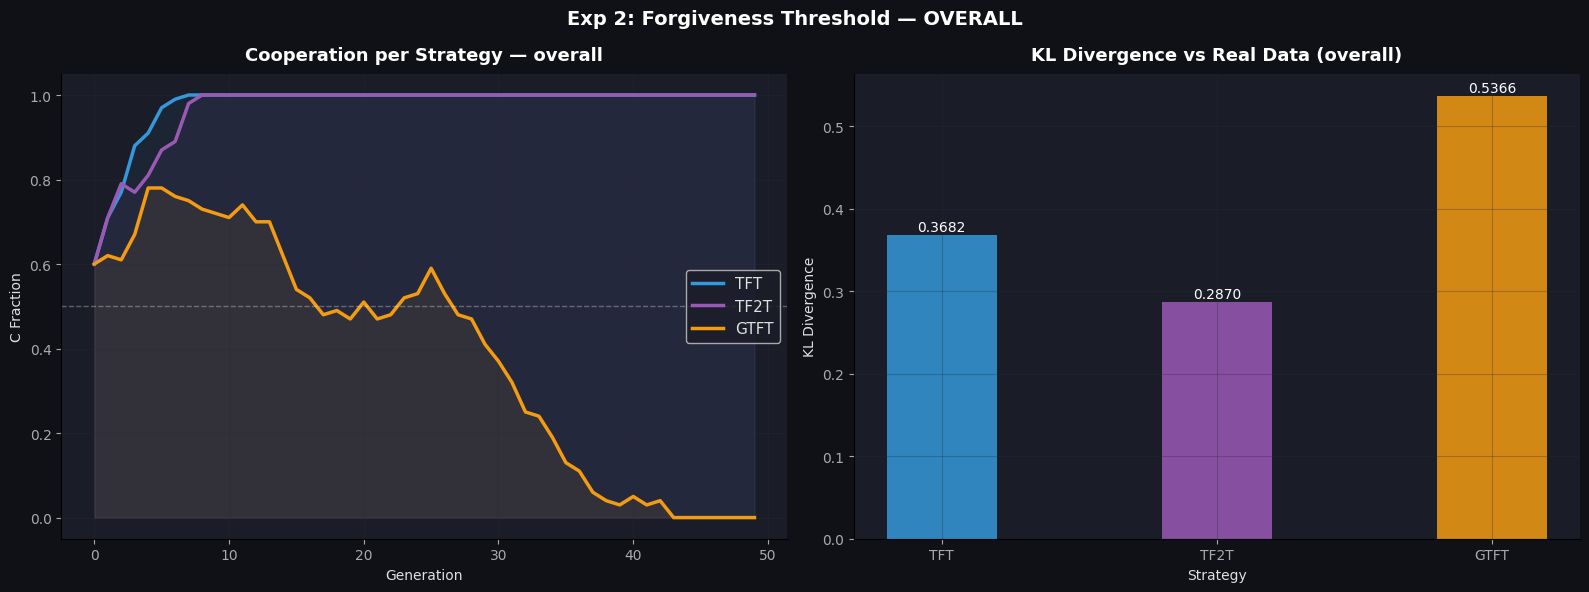

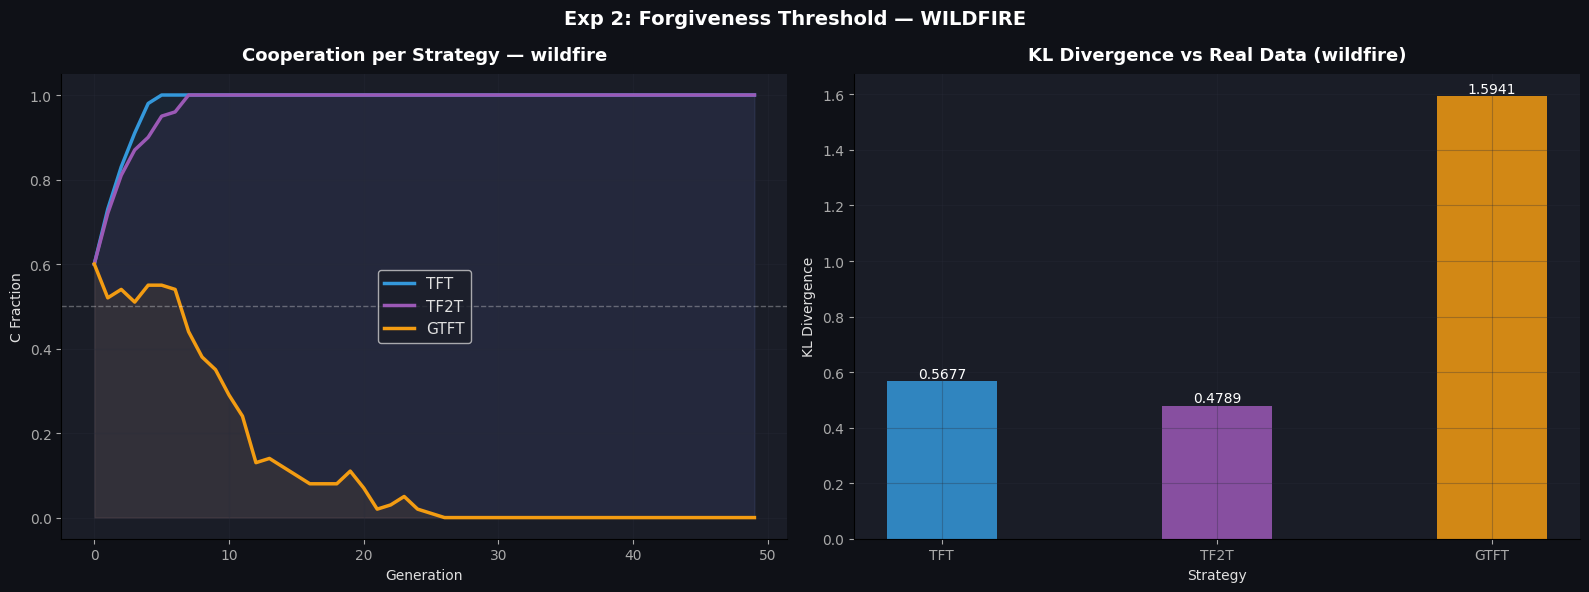

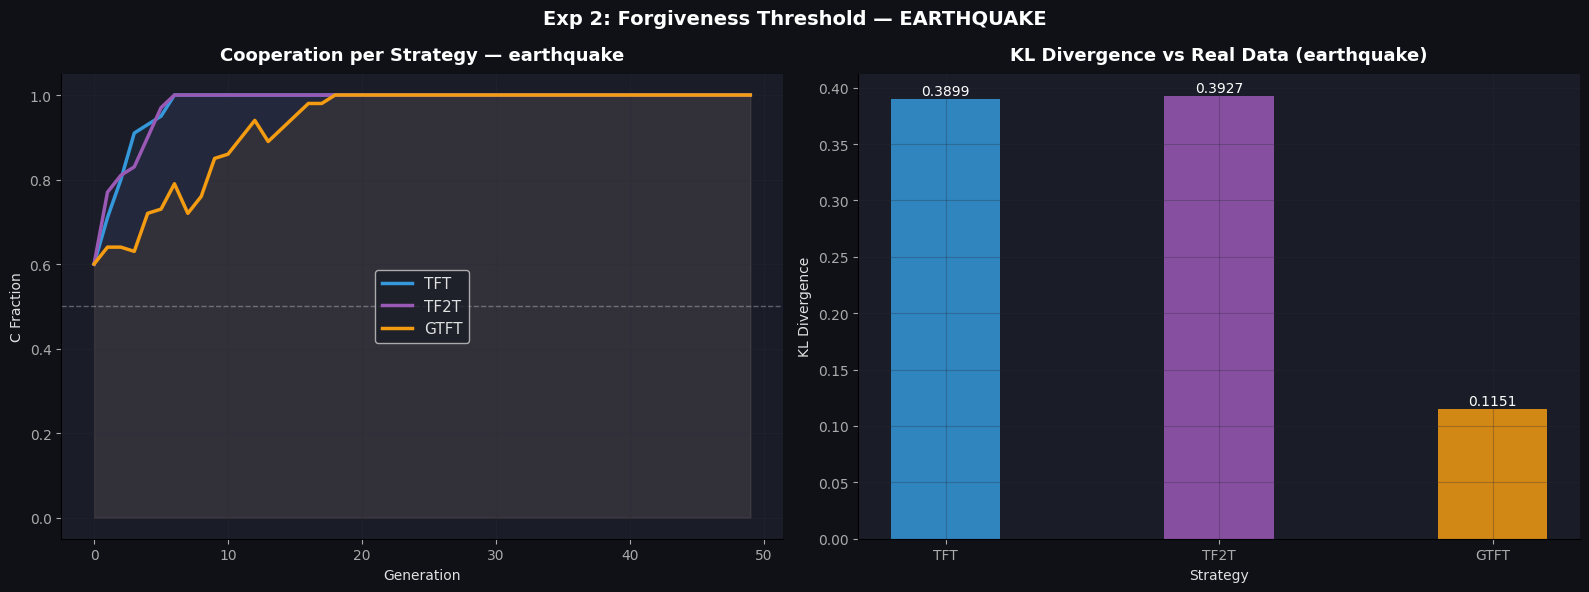

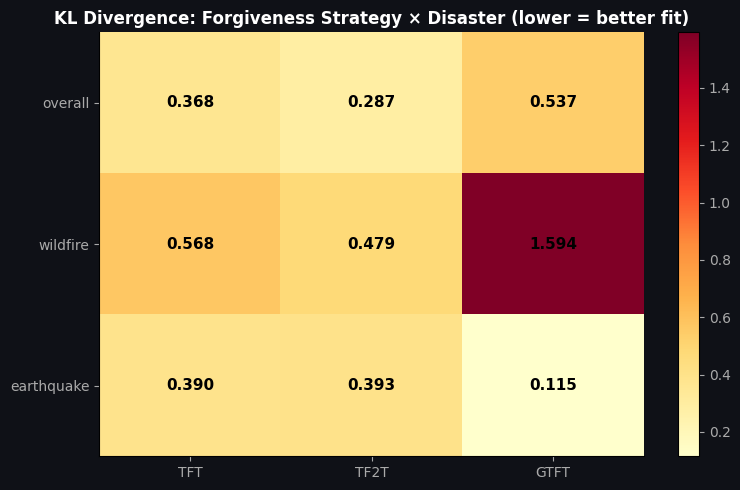

In [ ]:
palette_forg = {"TFT": COLORS["TFT"], "TF2T": COLORS["TF2T"], "GTFT": COLORS["GTFT"]}

for label, res in forgiveness_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
    fig.suptitle(f"Exp 2: Forgiveness Threshold — {label.upper()}",
                 fontsize=14, fontweight="bold", color="white")
    fig.patch.set_facecolor("#0f1117")

    ax = axes[0]; ax.set_facecolor("#1a1d27")
    for strat, cf in res["c_fracs"].items():
        ax.plot(gens, cf, lw=2.5, label=strat, color=palette_forg[strat])
        ax.fill_between(gens, cf, alpha=0.07, color=palette_forg[strat])
    ax.axhline(0.5, ls="--", color="white", alpha=0.3, lw=1)
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=11)
    _ax_style(ax, f"Cooperation per Strategy — {label}", "Generation", "C Fraction")

    ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
    labels_ = list(res["kl"].keys())
    values_ = list(res["kl"].values())
    bars = ax2.bar(labels_, values_, color=[palette_forg[l] for l in labels_], alpha=0.85, width=0.4)
    for bar, v in zip(bars, values_):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=10, color="white")
    _ax_style(ax2, f"KL Divergence vs Real Data ({label})", "Strategy", "KL Divergence")

    plt.tight_layout()
    plt.savefig(f"fig3_forgiveness_{label}.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()

# Heatmap across all three
kl_matrix = np.array(
    [[forgiveness_results[d]["kl"][s] for s in ["TFT","TF2T","GTFT"]]
     for d in forgiveness_results.keys()]
)
dtypes_list = list(forgiveness_results.keys())
fig, ax = plt.subplots(figsize=(8, 5), facecolor="#0f1117")
fig.patch.set_facecolor("#0f1117"); ax.set_facecolor("#1a1d27")
im = ax.imshow(kl_matrix, cmap="YlOrRd", aspect="auto")
ax.set_xticks([0,1,2]); ax.set_xticklabels(["TFT","TF2T","GTFT"])
ax.set_yticks(range(len(dtypes_list))); ax.set_yticklabels(dtypes_list)
for i in range(kl_matrix.shape[0]):
    for j in range(kl_matrix.shape[1]):
        ax.text(j, i, f"{kl_matrix[i,j]:.3f}", ha="center", va="center",
                color="black", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax)
ax.set_title("KL Divergence: Forgiveness Strategy × Disaster (lower = better fit)",
             fontsize=12, fontweight="bold", color="white")
plt.tight_layout()
plt.savefig("fig3b_forgiveness_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


Overall

TFT and TF2T converge quickly to full cooperation, while GTFT collapses due to excessive forgiveness. TF2T shows the best KL fit, indicating moderate forgiveness best matches observed behavior overall.


Wildfire

GTFT fails (cooperation → 0), while TFT and TF2T remain stable. TF2T fits best, indicating that in slow erosion environments, moderate punishment is optimal for sustaining cooperation under gradual stress.

Earthquake

All strategies recover cooperation, but GTFT performs best (lowest KL). This suggests that in sudden shocks, high forgiveness is beneficial for rapid recovery and re-alignment of cooperation.


## Experiment 3 — Hub Effect in Scale-Free Network

**Question:** Does placing an AD (defector) or AC (cooperator) at the most-connected node in a scale-free network change cooperation outcomes?

Scale-free networks model social media connectivity realistically — a few accounts (influencers, news outlets) have disproportionate reach.


In [ ]:
np.random.seed(2)
G_sf     = build_network("scale_free")
nodes_sf = list(G_sf.nodes())
hub      = max(dict(G_sf.degree()), key=lambda k: G_sf.degree(k))
hub_idx  = nodes_sf.index(hub)
print(f"Hub node: {hub}  |  Degree: {G_sf.degree(hub)}")

hub_results = {}

for label in ["overall"] + list(disaster_freq.keys()):
    strats_ad = ["TFT"] * N_AGENTS
    strats_ad[hub_idx] = "AD"
    hist_ad, final_ad, _ = run_ipd_simulation(
        strats_ad, G_sf, n_generations=N_GENERATIONS, track_strategies=["TFT","AD"])
    _, c_fracs_ad = compute_sim_transition(hist_ad)

    strats_ac = ["TFT"] * 70 + ["AD"] * 30
    np.random.shuffle(strats_ac)
    strats_ac[hub_idx] = "AC"
    hist_ac, final_ac, _ = run_ipd_simulation(
        strats_ac, G_sf, n_generations=N_GENERATIONS, track_strategies=["TFT","AD","AC"])
    _, c_fracs_ac = compute_sim_transition(hist_ac)

    hub_results[label] = {
        "ad": {"c_fracs": c_fracs_ad, "hist": hist_ad, "init": list(strats_ad), "final": final_ad},
        "ac": {"c_fracs": c_fracs_ac, "hist": hist_ac, "final": final_ac},
    }
    print(f"{label:12s} — AD@hub final: TFT={final_ad.count('TFT')} AD={final_ad.count('AD')}")


Hub node: 4  |  Degree: 30
overall      — AD@hub final: TFT=100 AD=0
wildfire     — AD@hub final: TFT=100 AD=0
earthquake   — AD@hub final: TFT=100 AD=0


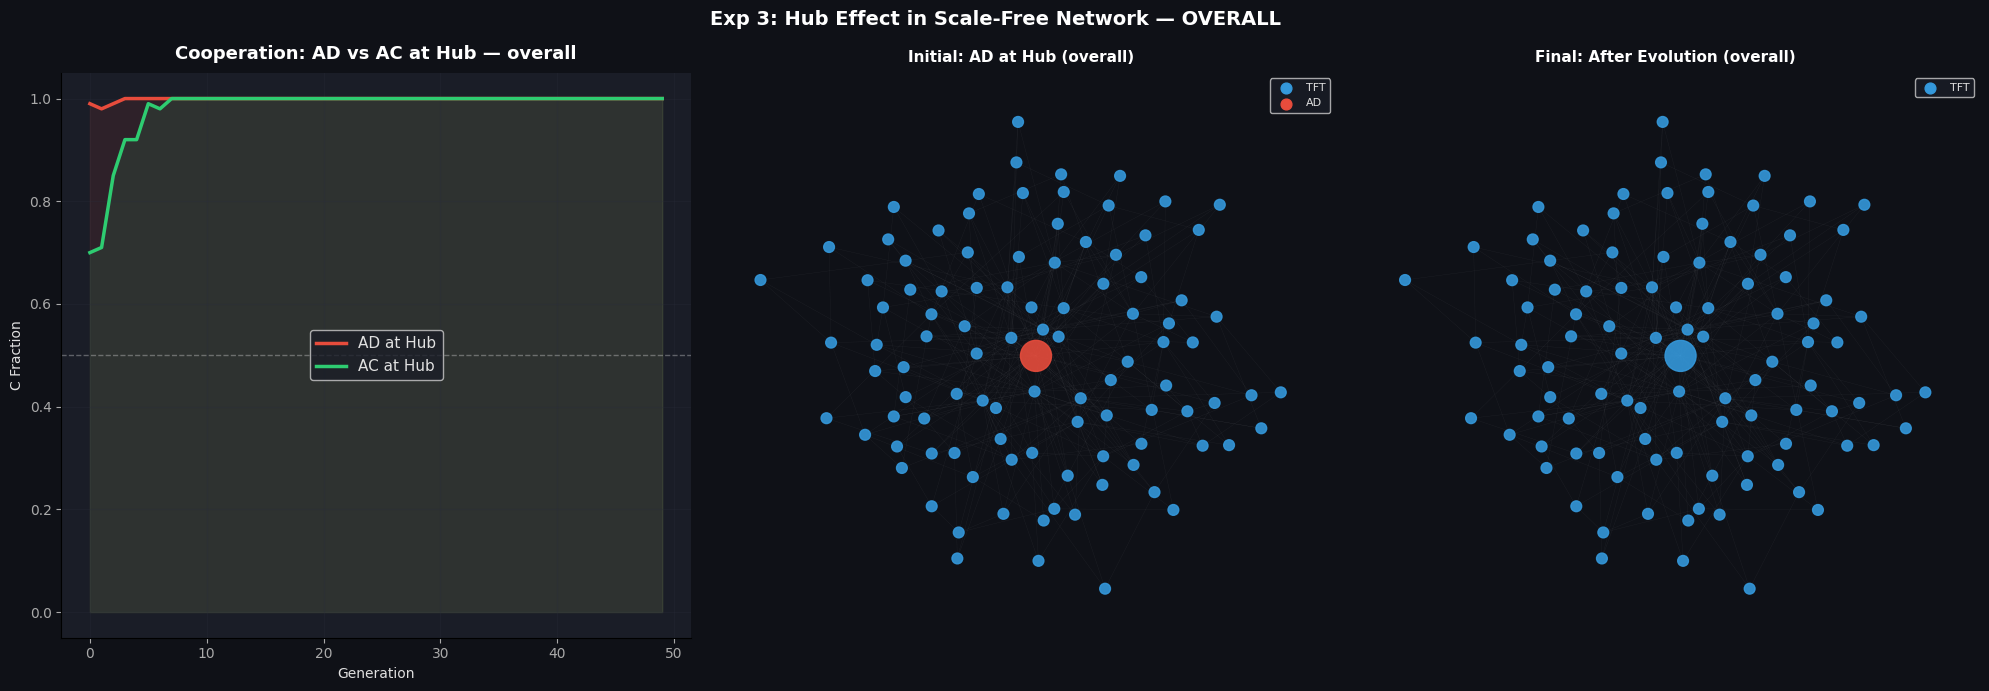

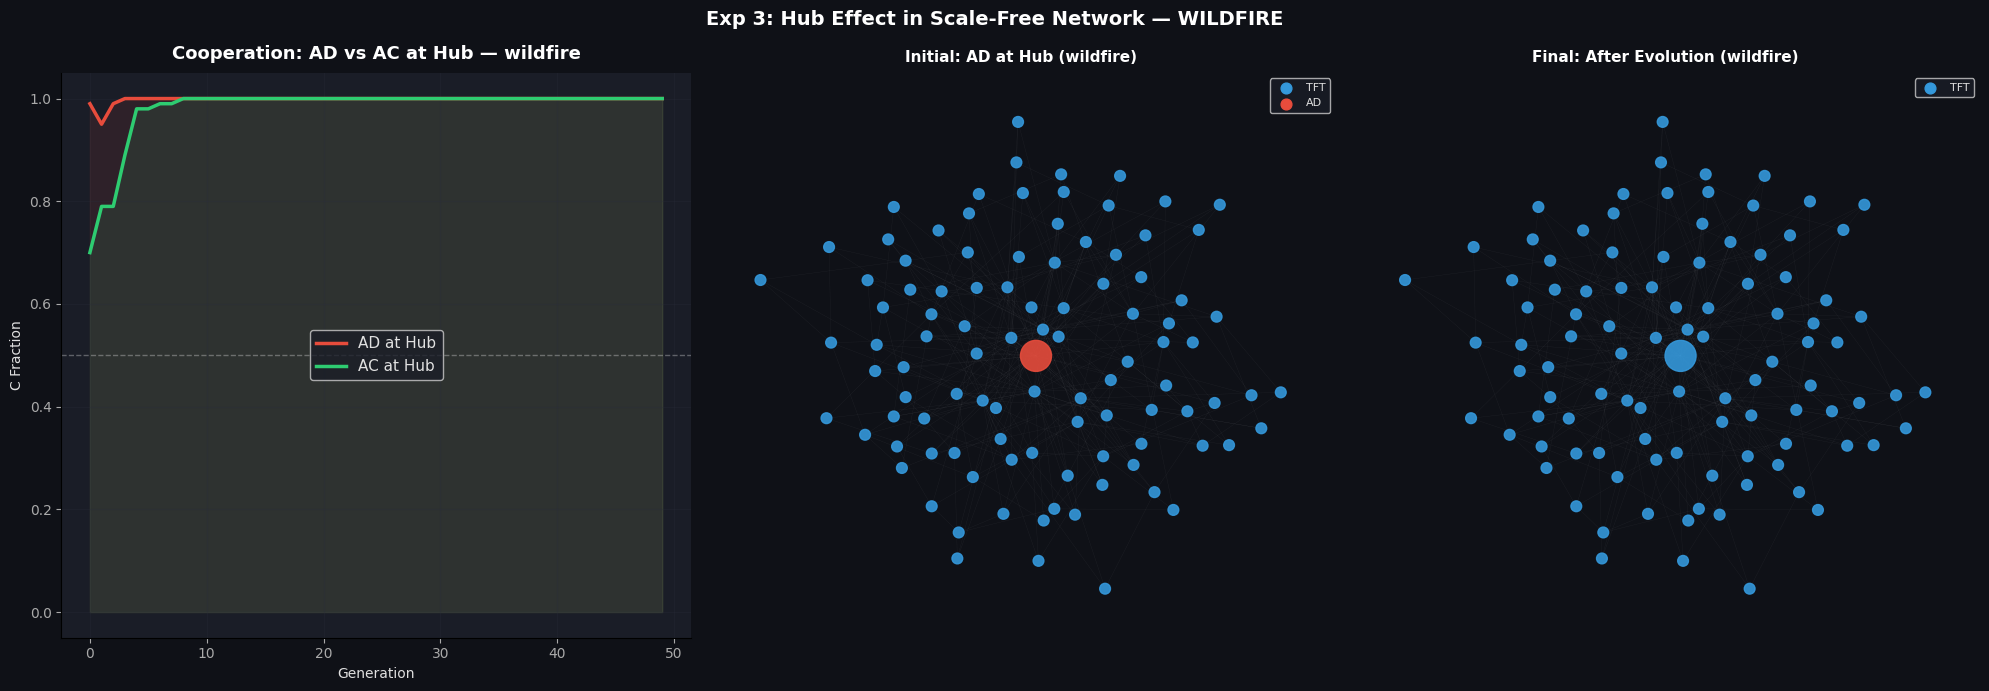

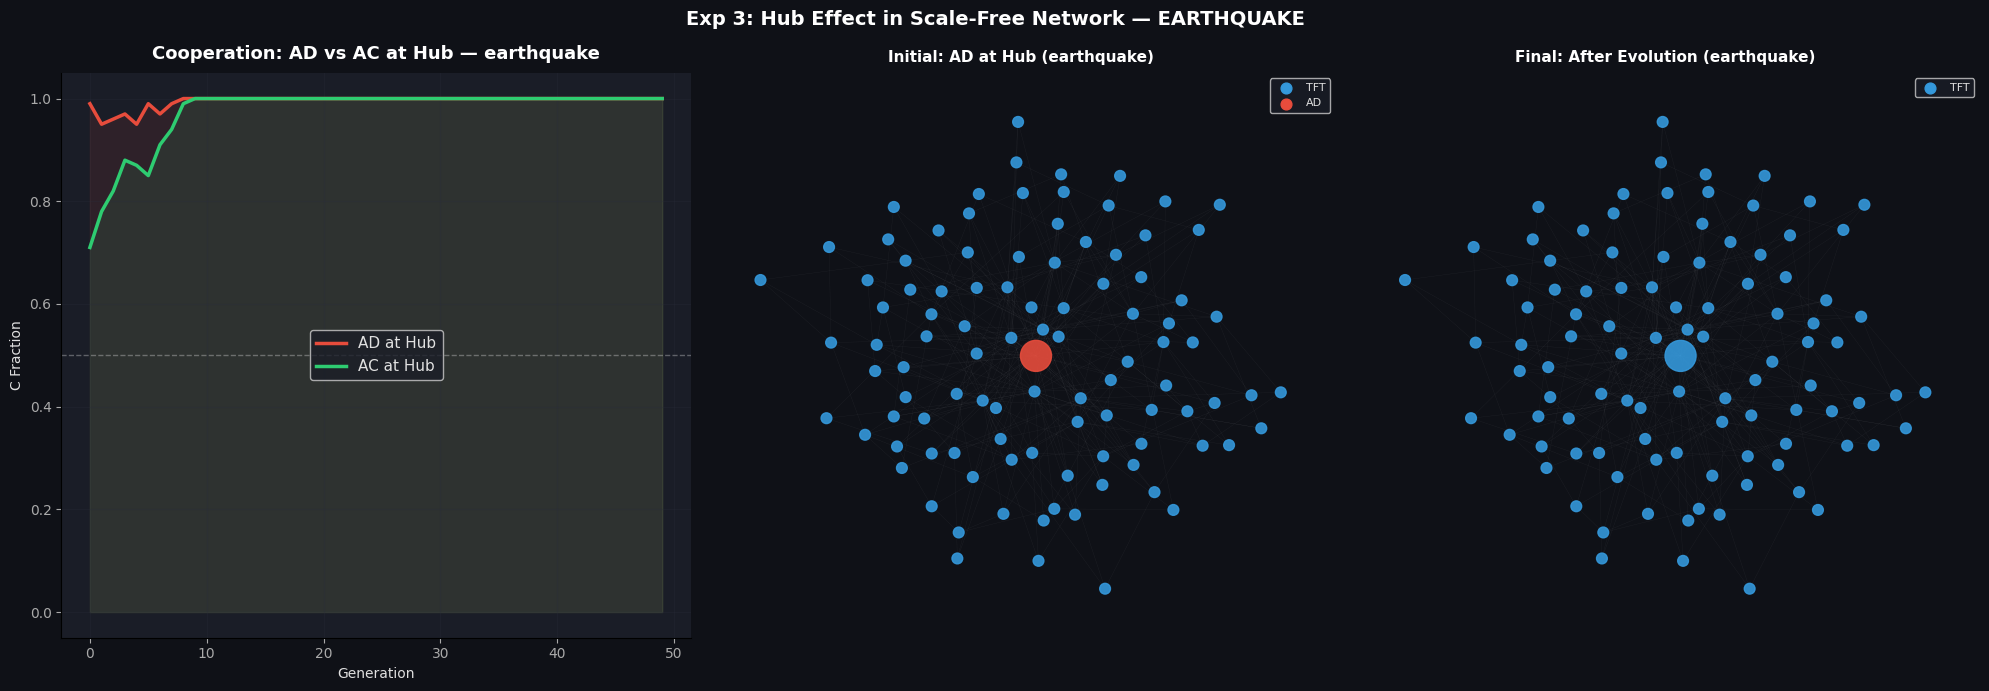

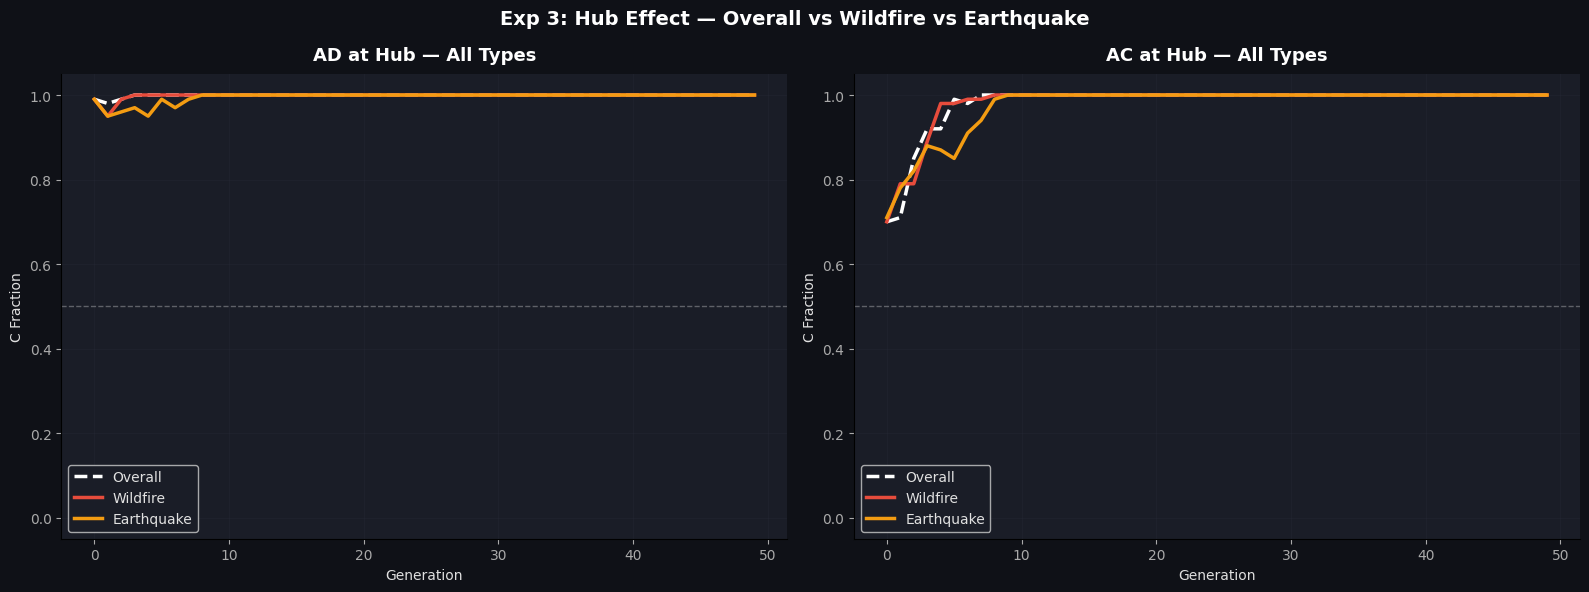

In [ ]:
def draw_net(ax, G, strats, title):
    ax.set_facecolor("#0a0a0f")
    degrees = dict(G.degree())
    hub_n   = max(degrees, key=degrees.get)
    pos     = nx.spring_layout(G, seed=42, k=0.3)
    pos[hub_n] = np.array([0.0, 0.0])
    node_colors = [COLORS.get(strats[i], "#cccccc") for i in range(len(G.nodes()))]
    node_sizes  = [500 if i == list(G.nodes()).index(hub_n) else 60 for i in range(len(G.nodes()))]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.06, edge_color="white", width=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    seen = set()
    for s in strats:
        if s not in seen:
            ax.scatter([], [], c=COLORS.get(s, "#cccccc"), label=s, s=60)
            seen.add(s)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(title, fontsize=11, fontweight="bold", color="white", pad=8)
    ax.axis("off")

for label, res in hub_results.items():
    fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor="#0f1117")
    fig.suptitle(f"Exp 3: Hub Effect in Scale-Free Network — {label.upper()}",
                 fontsize=14, fontweight="bold", color="white")
    fig.patch.set_facecolor("#0f1117")
    ax = axes[0]; ax.set_facecolor("#1a1d27")
    ax.plot(gens, res["ad"]["c_fracs"], lw=2.5, color=COLORS["AD"], label="AD at Hub")
    ax.fill_between(gens, res["ad"]["c_fracs"], alpha=0.1, color=COLORS["AD"])
    ax.plot(gens, res["ac"]["c_fracs"], lw=2.5, color=COLORS["AC"], label="AC at Hub")
    ax.fill_between(gens, res["ac"]["c_fracs"], alpha=0.1, color=COLORS["AC"])
    ax.axhline(0.5, ls="--", color="white", alpha=0.3, lw=1)
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=11)
    _ax_style(ax, f"Cooperation: AD vs AC at Hub — {label}", "Generation", "C Fraction")
    draw_net(axes[1], G_sf, res["ad"]["init"], f"Initial: AD at Hub ({label})")
    draw_net(axes[2], G_sf, res["ad"]["final"], f"Final: After Evolution ({label})")
    plt.tight_layout()
    plt.savefig(f"fig4_hub_{label}.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()

# Cross-comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
fig.suptitle("Exp 3: Hub Effect — Overall vs Wildfire vs Earthquake", fontsize=14, fontweight="bold", color="white")
fig.patch.set_facecolor("#0f1117")
for ax_idx, hub_type in enumerate(["ad", "ac"]):
    ax = axes[ax_idx]; ax.set_facecolor("#1a1d27")
    for label, res in hub_results.items():
        ax.plot(gens, res[hub_type]["c_fracs"], lw=2.5,
                label=label.capitalize(), color=DISASTER_COLORS.get(label, "#ffffff"),
                ls="--" if label == "overall" else "-")
    ax.axhline(0.5, ls="--", color="white", alpha=0.3, lw=1)
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=10)
    lab = "AD" if hub_type == "ad" else "AC"
    _ax_style(ax, f"{lab} at Hub — All Types", "Generation", "C Fraction")
plt.tight_layout()
plt.savefig("fig4b_hub_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


Overall

Both AD-at-hub and AC-at-hub cases converge rapidly to full cooperation (~100%). Even when a defector occupies the hub, it is quickly outcompeted and replaced.


Wildfire

Slight early volatility, but convergence to full cooperation occurs by 15–20 generations. AC-at-hub starts higher (~70%) and stabilizes faster, reflecting gradual reinforcement advantages in prolonged environments.


Earthquake

More early instability, especially in AC-at-hub. However, both conditions still converge by ~20–25 generations.

## Experiment 4 — Noise vs Strict Punishment (Grim Trigger)

**Question:** Should disaster platform moderation be zero-tolerance (Grim Trigger) or forgiving (GTFT)?  
Noise (0%, 5%, 15%) models accidental defection — misinterpreted tweets, auto-moderation errors, or ambiguous content.



In [ ]:
np.random.seed(3)
noise_results_all = {}

for label in ["overall"] + list(disaster_freq.keys()):
    noise_results = {}
    for noise_level, noise_label in [
        (0.00, "GT — No Noise"),
        (0.05, "GT — 5% Noise"),
        (0.15, "GT — 15% Noise"),
    ]:
        mix = ["GT"] * 50 + ["TFT"] * 30 + ["AD"] * 20
        np.random.shuffle(mix)
        h, _, _ = run_ipd_simulation(mix, build_network("fully_connected"),
                                      n_generations=N_GENERATIONS, noise=noise_level,
                                      track_strategies=["GT","TFT","AD"])
        _, cf = compute_sim_transition(h)
        noise_results[noise_label] = cf

    mix_gtft = ["GTFT"] * 50 + ["TFT"] * 30 + ["AD"] * 20
    np.random.shuffle(mix_gtft)
    h_gtft, _, _ = run_ipd_simulation(mix_gtft, build_network("fully_connected"),
                                        n_generations=N_GENERATIONS, noise=0.05,
                                        track_strategies=["GTFT","TFT","AD"])
    _, cf_gtft = compute_sim_transition(h_gtft)
    noise_results["GTFT — 5% Noise"] = cf_gtft
    noise_results_all[label] = noise_results
    print(f"{label} — Exp 4 complete.")


overall — Exp 4 complete.
wildfire — Exp 4 complete.
earthquake — Exp 4 complete.


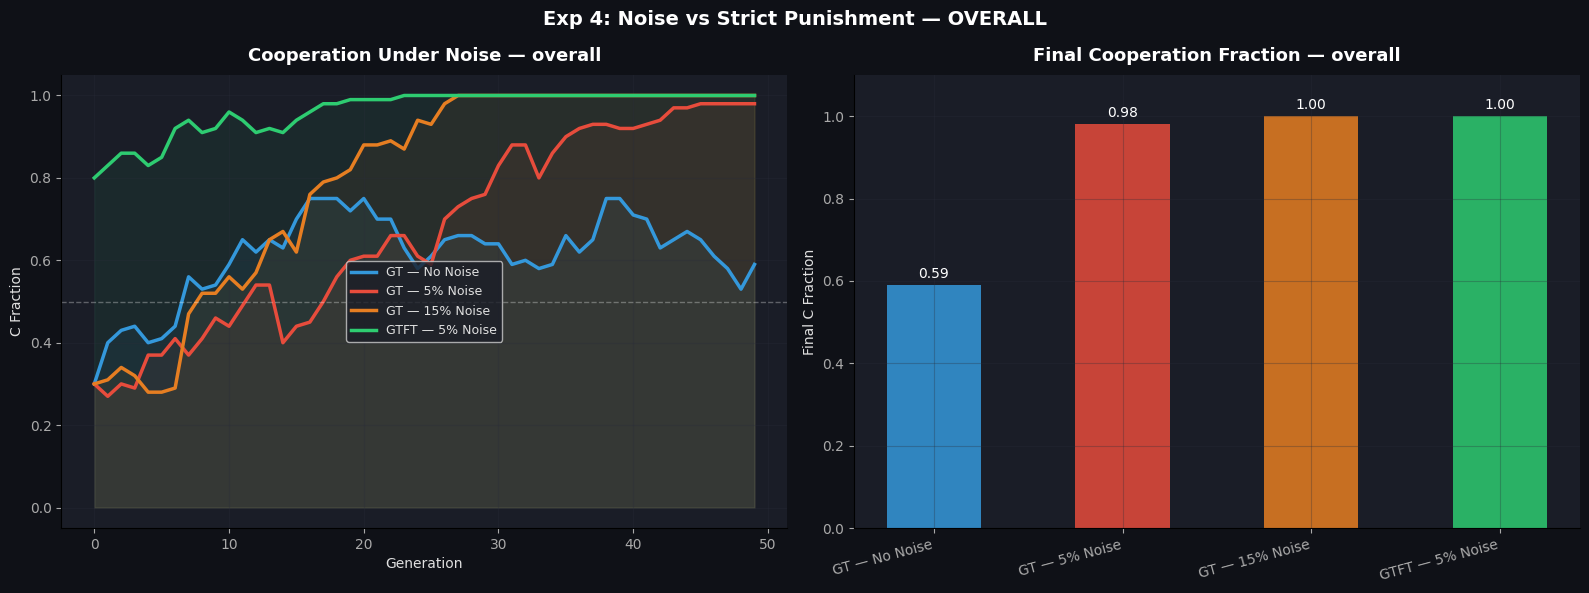

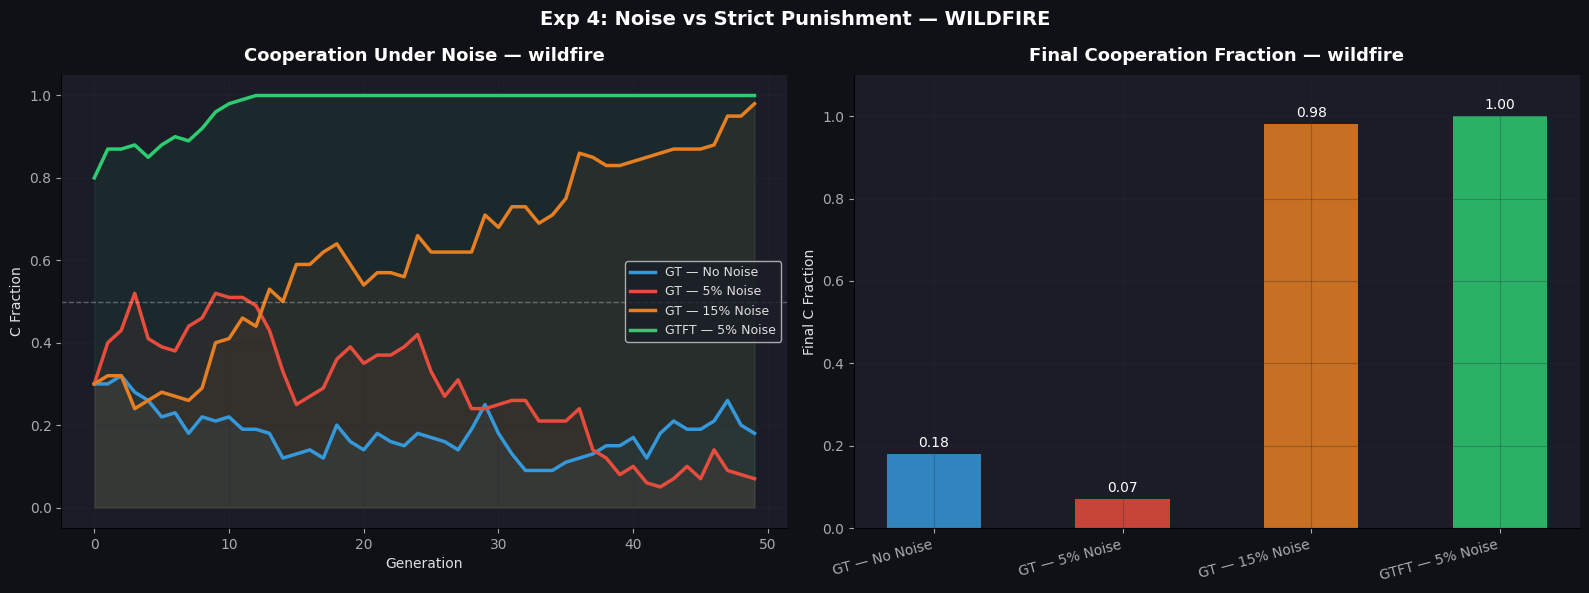

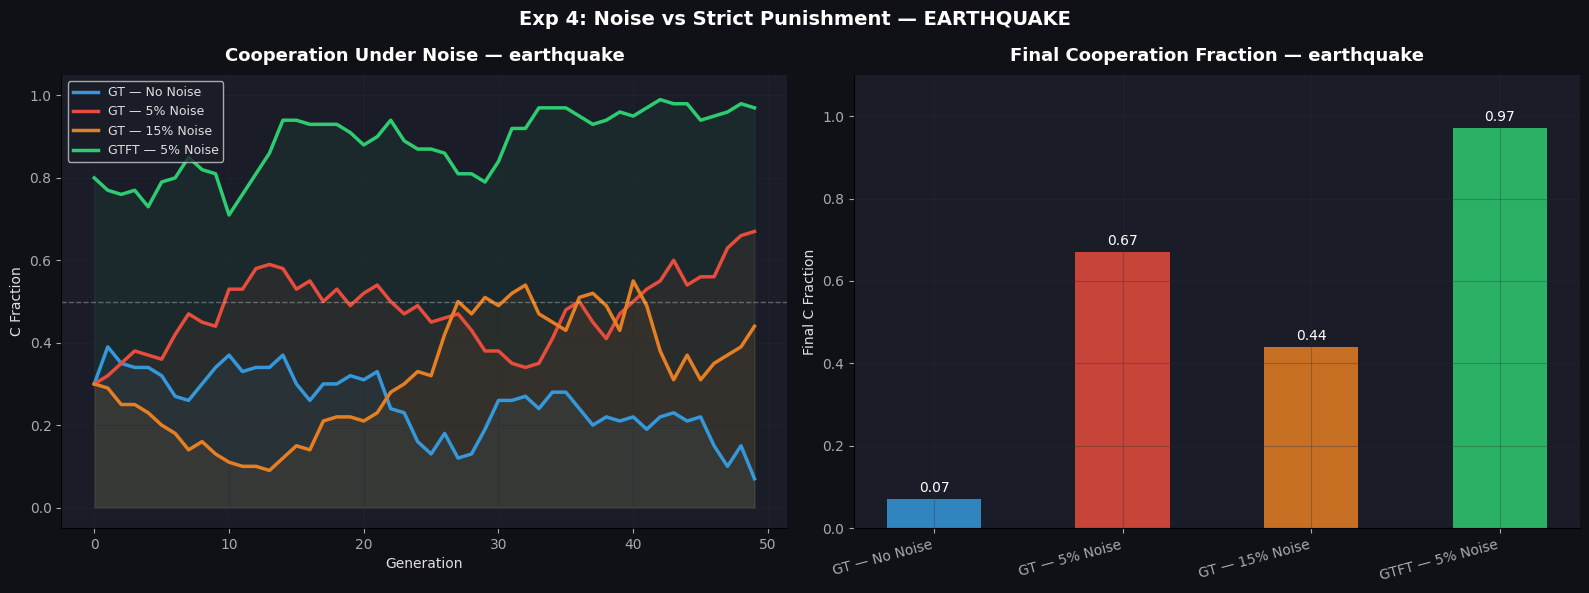

In [ ]:
palette4 = ["#3498db", "#e74c3c", "#e67e22", "#2ecc71"]

for label, noise_results in noise_results_all.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
    fig.suptitle(f"Exp 4: Noise vs Strict Punishment — {label.upper()}",
                 fontsize=14, fontweight="bold", color="white")
    fig.patch.set_facecolor("#0f1117")
    ax = axes[0]; ax.set_facecolor("#1a1d27")
    for (noise_label, cf), col in zip(noise_results.items(), palette4):
        ax.plot(gens, cf, lw=2.5, label=noise_label, color=col)
        ax.fill_between(gens, cf, alpha=0.07, color=col)
    ax.axhline(0.5, ls="--", color="white", alpha=0.3, lw=1)
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9)
    _ax_style(ax, f"Cooperation Under Noise — {label}", "Generation", "C Fraction")
    ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
    final_cf = {k: v[-1] for k, v in noise_results.items()}
    bars = ax2.bar(final_cf.keys(), final_cf.values(), color=palette4, alpha=0.85, width=0.5)
    for bar, v in zip(bars, final_cf.values()):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.2f}", ha="center", va="bottom", fontsize=10, color="white")
    ax2.set_xticklabels(final_cf.keys(), rotation=15, ha="right")
    ax2.set_ylim(0, 1.1)
    _ax_style(ax2, f"Final Cooperation Fraction — {label}", "", "Final C Fraction")
    plt.tight_layout()
    plt.savefig(f"fig5_noise_{label}.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()


Noise acts as a stress-test of forgiveness mechanisms: strict strategies fail under observational error, while forgiving strategies convert moderate noise into a stabilizing signal but collapse under excessive corruption.

Overall

GTFT (5% noise) performs best, reaching stable cooperation (~1.0). Interestingly, moderate noise (5%) improves cooperative stability in GTFT settings by introducing small perturbations that allow recovery dynamics to activate and reinforce cooperation. However, higher noise levels (15%) degrade performance due to excessive false defections that overwhelm the system’s ability to recover.


Wildfire (slow-onset)

GT fails severely (0.18 → 0.07), showing that in prolonged stress environments, zero-tolerance punishment leads to collapse due to accumulated errors.

GTFT remains stable (0.8 → 1.0), absorbing noise effectively.


Earthquake (fast-onset)

GT collapses under all noise settings (0.07–0.67 range), while GTFT remains robust (0.75 → 0.97).

## Strategy Mixture Fitting to Real Data

Find **θ*** — the mixture of strategies minimising MSE between simulated and observed C fractions.  

**θ* = argmin Σ (P_data - P_sim)²**


In [ ]:
def fit_strategy_mix(obs_c_fracs, candidate_strategies, G, n_trials=20):
    best_mse, best_theta, best_history = np.inf, None, None
    for _ in range(n_trials):
        theta  = np.random.dirichlet(np.ones(len(candidate_strategies)))
        counts = (theta * N_AGENTS).astype(int)
        counts[-1] = N_AGENTS - counts[:-1].sum()
        strats = []
        for s, c in zip(candidate_strategies, counts):
            strats.extend([s] * max(0, c))
        strats = strats[:N_AGENTS]
        while len(strats) < N_AGENTS:
            strats.append(candidate_strategies[0])
        h, _, _ = run_ipd_simulation(strats, G, n_generations=len(obs_c_fracs))
        _, sim_cf = compute_sim_transition(h)
        n = min(len(obs_c_fracs), len(sim_cf))
        mse = np.mean((np.array(obs_c_fracs[:n]) - np.array(sim_cf[:n]))**2)
        if mse < best_mse:
            best_mse, best_theta, best_history = mse, theta, h
    return best_theta, best_mse, best_history

np.random.seed(42)
candidate_strats = ["AC", "AD", "TFT", "TF2T", "GTFT", "GT"]
fit_results = {}

# Overall
obs_c_overall = [overall_freq[b]["C"] for b in overall_freq]
obs_b_overall = list(overall_freq.keys())
theta, mse, hist_fit = fit_strategy_mix(obs_c_overall, candidate_strats,
                                         build_network("fully_connected"), n_trials=20)
fit_results["overall"] = {"theta": theta, "mse": mse, "hist": hist_fit,
                           "obs_c": obs_c_overall, "obs_bins": obs_b_overall}
print(f"OVERALL (MSE={mse:.5f}):")
for s, w in zip(candidate_strats, theta): print(f"  {s}: {w:.3f}")

# Per disaster type
for dtype in list(disaster_freq.keys()):
    obs_c = [disaster_freq[dtype][b]["C"] for b in disaster_freq[dtype]]
    obs_b = list(disaster_freq[dtype].keys())
    theta, mse, hist_fit = fit_strategy_mix(obs_c, candidate_strats,
                                             build_network("fully_connected"), n_trials=20)
    fit_results[dtype] = {"theta": theta, "mse": mse, "hist": hist_fit,
                           "obs_c": obs_c, "obs_bins": obs_b}
    print(f"\n{dtype.upper()} (MSE={mse:.5f}):")
    for s, w in zip(candidate_strats, theta): print(f"  {s}: {w:.3f}")


OVERALL (MSE=0.00913):
  AC: 0.292
  AD: 0.252
  TFT: 0.302
  TF2T: 0.037
  GTFT: 0.056
  GT: 0.062

WILDFIRE (MSE=0.00517):
  AC: 0.176
  AD: 0.011
  TFT: 0.020
  TF2T: 0.436
  GTFT: 0.065
  GT: 0.292

EARTHQUAKE (MSE=0.00336):
  AC: 0.263
  AD: 0.152
  TFT: 0.134
  TF2T: 0.173
  GTFT: 0.174
  GT: 0.104


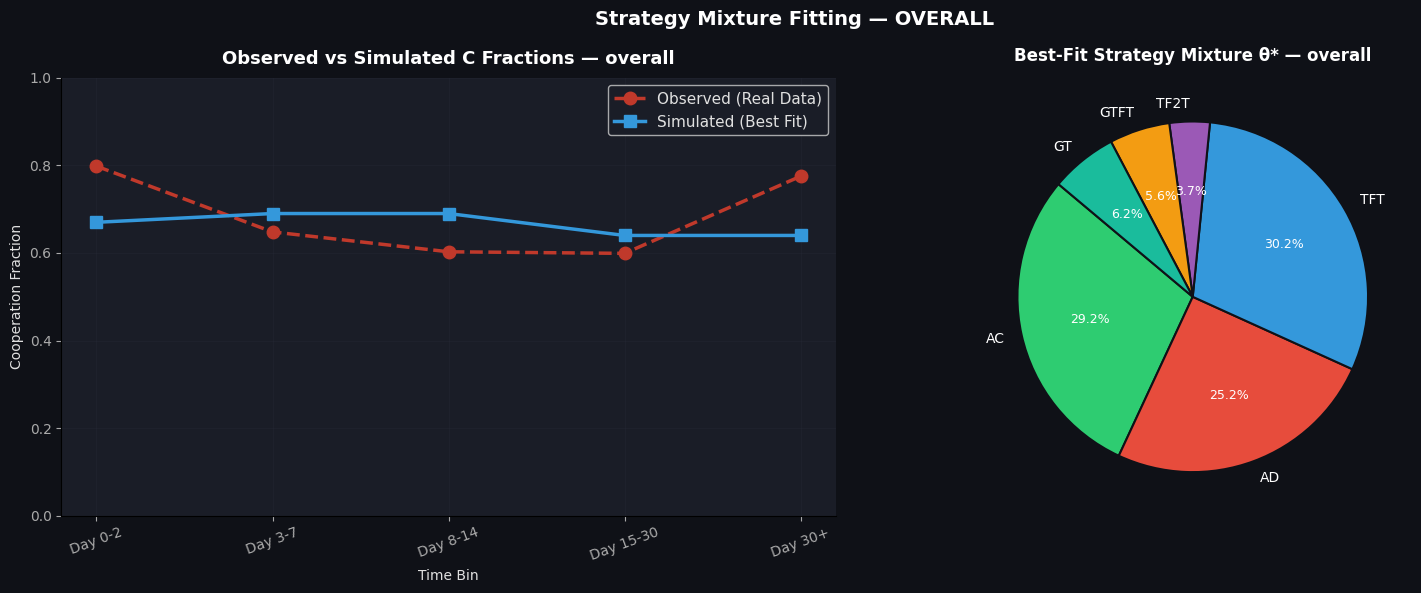

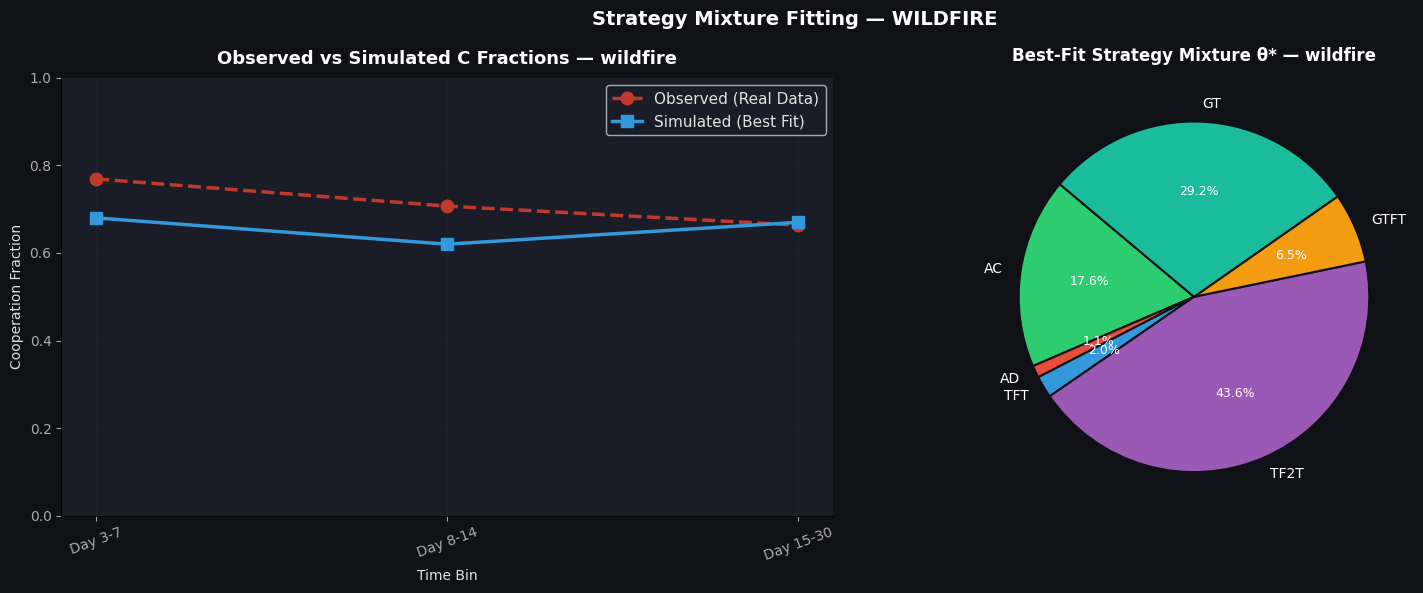

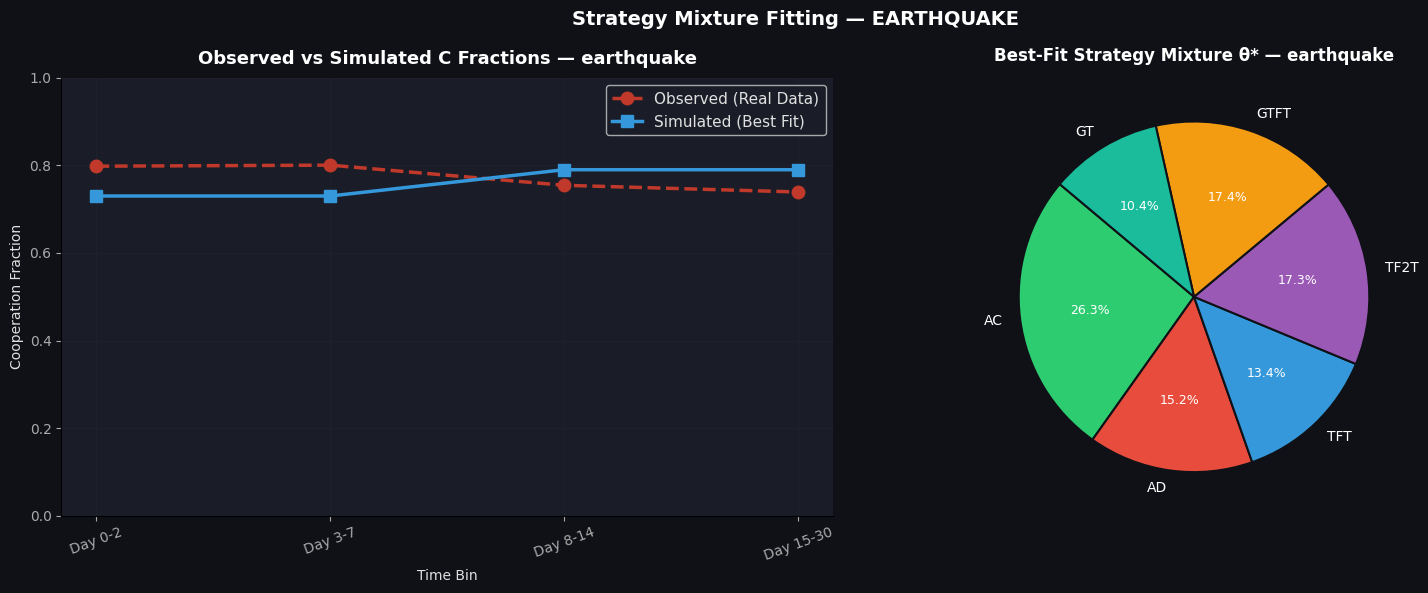

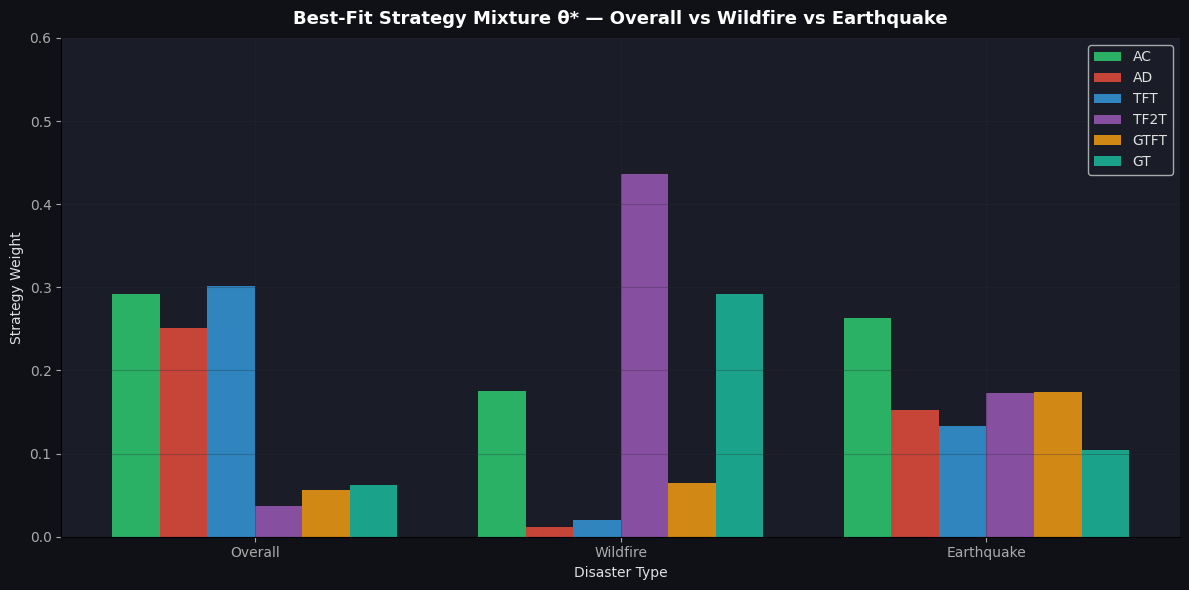

In [ ]:
pie_colors = [COLORS.get(s, "#cccccc") for s in candidate_strats]

for label, res in fit_results.items():
    _, c_fracs_fit = compute_sim_transition(res["hist"])
    obs_c = res["obs_c"]; obs_b = res["obs_bins"]
    n = min(len(obs_c), len(c_fracs_fit))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
    fig.suptitle(f"Strategy Mixture Fitting — {label.upper()}",
                 fontsize=14, fontweight="bold", color="white")
    fig.patch.set_facecolor("#0f1117")

    ax = axes[0]; ax.set_facecolor("#1a1d27")
    ax.plot(range(n), obs_c[:n], "o--", lw=2.5, color=COLORS["D"],
            label="Observed (Real Data)", markersize=9)
    ax.plot(range(n), c_fracs_fit[:n], "s-", lw=2.5, color=COLORS["TFT"],
            label="Simulated (Best Fit)", markersize=9)
    ax.set_xticks(range(n)); ax.set_xticklabels(obs_b[:n], rotation=20)
    ax.set_ylim(0, 1); ax.legend(fontsize=11)
    _ax_style(ax, f"Observed vs Simulated C Fractions — {label}", "Time Bin", "Cooperation Fraction")

    ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
    wedges, texts, autotexts = ax2.pie(
        res["theta"], labels=candidate_strats, colors=pie_colors,
        autopct="%1.1f%%", startangle=140,
        textprops={"color": "white", "fontsize": 10},
        wedgeprops={"edgecolor": "#0f1117", "linewidth": 1.5}
    )
    for at in autotexts: at.set_color("white"); at.set_fontsize(9)
    ax2.set_title(f"Best-Fit Strategy Mixture θ* — {label}",
                  fontsize=12, fontweight="bold", color="white", pad=12)
    plt.tight_layout()
    plt.savefig(f"fig6_fit_{label}.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()

# Cross-disaster θ* bar chart
theta_matrix = np.array([fit_results[d]["theta"] for d in fit_results])
labels_list  = list(fit_results.keys())
fig, ax = plt.subplots(figsize=(12, 6), facecolor="#0f1117")
fig.patch.set_facecolor("#0f1117"); ax.set_facecolor("#1a1d27")
x = np.arange(len(labels_list)); w = 0.13
for i, s in enumerate(candidate_strats):
    ax.bar(x + i*w, theta_matrix[:, i], w, label=s, color=COLORS.get(s, "#cccccc"), alpha=0.85)
ax.set_xticks(x + w * (len(candidate_strats)-1)/2)
ax.set_xticklabels([d.capitalize() for d in labels_list])
ax.legend(fontsize=10); ax.set_ylim(0, 0.6)
_ax_style(ax, "Best-Fit Strategy Mixture θ* — Overall vs Wildfire vs Earthquake",
          "Disaster Type", "Strategy Weight")
plt.tight_layout()
plt.savefig("fig6b_mixture_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


## Strategy Mixture Fitting to Real Data

Overall (MSE = 0.00913)

Mix dominated by TFT (30%), AC (29%), AD (25%). This reflects a heterogeneous population with both cooperators and persistent defectors.


Wildfire (slow-onset) (MSE = 0.00517)

TF2T (43.6%) and GT (29.2%) dominate. Indicates polarization under prolonged stress: cautious cooperators + strict punishers.


Earthquake (fast-onset) (MSE = 0.00336)

All strategies coexist with no single dominance, matching stable cooperation dynamics after shock recovery.

## Summary: KL Divergence Across All Experiments

Which simulated dynamics best explain each disaster type's real observed transition probabilities?


              base  forgive_TFT  forgive_TF2T  forgive_GTFT  hub_AD  hub_AC
disaster                                                                   
overall     0.2446       0.3682        0.2870        0.5366  1.6326  0.4173
wildfire    0.0235       0.5677        0.4789        1.5941  1.5285  0.5520
earthquake  0.3134       0.3899        0.3927        0.1151  0.9930  0.3563


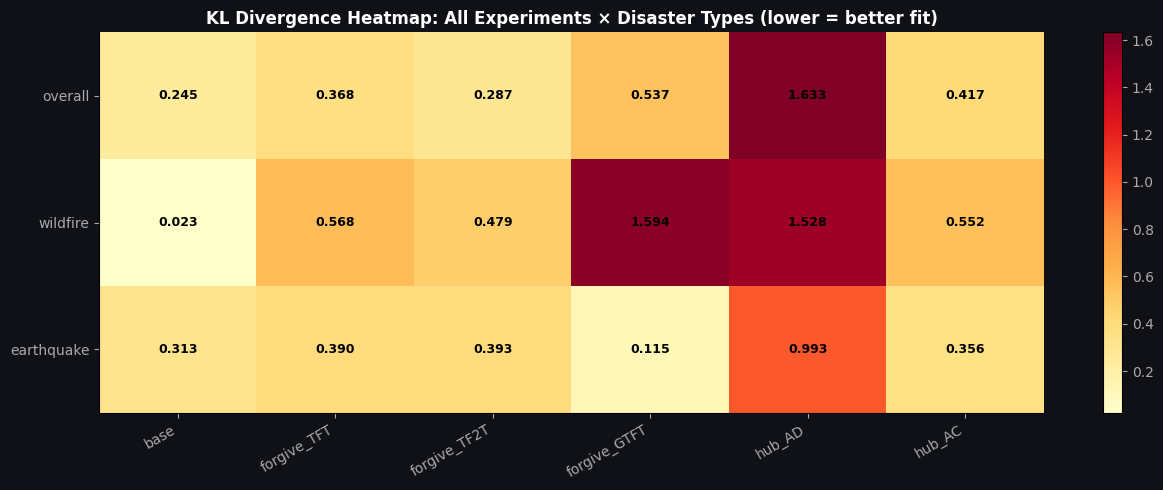

In [ ]:
summary_rows = []

for label in ["overall"] + list(disaster_freq.keys()):
    if label == "overall":
        ref_tm = list(overall_trans.values())[0]
    else:
        ref_tm = list(disaster_trans[label].values())[0]

    row = {"disaster": label}
    row["base"]          = base_results[label]["kl"]
    for s in ["TFT", "TF2T", "GTFT"]:
        row[f"forgive_{s}"] = forgiveness_results[label]["kl"][s]
    row["hub_AD"] = kl_divergence(ref_tm, compute_sim_transition(hub_results[label]["ad"]["hist"])[0])
    row["hub_AC"] = kl_divergence(ref_tm, compute_sim_transition(hub_results[label]["ac"]["hist"])[0])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("disaster")
print(summary_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(13, 5), facecolor="#0f1117")
fig.patch.set_facecolor("#0f1117"); ax.set_facecolor("#1a1d27")
data = summary_df.values
im = ax.imshow(data, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(summary_df.columns)))
ax.set_xticklabels(summary_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(summary_df.index)))
ax.set_yticklabels(summary_df.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i,j]:.3f}", ha="center", va="center",
                color="black", fontsize=9, fontweight="bold")
plt.colorbar(im, ax=ax)
ax.set_title("KL Divergence Heatmap: All Experiments × Disaster Types (lower = better fit)",
             fontsize=12, fontweight="bold", color="white")
plt.tight_layout()
plt.savefig("fig7_kl_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


Across all experiments, disaster dynamics can be understood along a single axis:

Slow-onset stress (wildfires) leads to gradual erosion and strategic polarization, while fast-onset shocks (earthquakes) trigger rapid synchronization and recovery-driven cooperation.

Despite these differences, cooperative systems remain robust due to:

-	reciprocal strategies (TFT, TF2T)
- forgiving mechanisms (GTFT)
- structural network effects